# Schnitt-Extraktion aus axon_logger-MongoDB-JSON

**Vertraulichkeitshinweis:** Dieses Notebook verarbeitet Maschinen-, Prozess- und Werkstueckdaten
aus dem PTW-Versuchsaufbau (Hermle C32U / SINUMERIK 840D sl, Kistler-Kraftmessplatte). Die gesamte
Verarbeitung laeuft lokal -- es findet keine Netzwerkuebertragung statt. Bitte Notebook-Outputs
(Pfade, Seriennummern in `workpiecedata`) vor externer Weitergabe pruefen.

**Ziel:** Aus dem als MongoDB-Export vorliegenden JSON (`axon_logger_ptw_Lev022_raw.json`) werden
die Kraftdaten (`force_0/1/2`, 20 kHz) und die Achsdaten (Spindel + Vorschubachsen, 250 Hz, aus
`sensortype == "machine"`) extrahiert, in einzelne Schnitte segmentiert (4 Schnitte je Block,
getrennt durch Spindel-/Vorschubstopp) und je Schnitt als CSV (SinuTrace-Stil) exportiert.
Zusaetzlich wird pro Schnitt ein winkelaufgeloestes Radialkraft-Profil an der Schneidkante
berechnet (Basis fuer die spaetere $a_E/D$-Schaetzung).

**Segmentierungslogik (mit dir abgestimmt):**
- Bloecke = zusammenhaengende Force-Bursts >= `min_block_duration_s`.
- Einzelne Schnitte innerhalb eines Blocks = Richtungsumkehr der dominanten Vorschubachse
  (axis4/5/6), da die Spindel innerhalb eines 4er-Blocks durchgehend laeuft.
- Export nur Spindel (axis0) + Vorschubachsen (axis4, axis5, axis6) -- nicht alle 9 Achsen.


In [ ]:
%load_ext autoreload
%autoreload 2

import sys, warnings
sys.path.insert(0, '../py')  # kienzle_utils.py und cnc_cut_extractor.py liegen in py/src

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.kienzle_utils import MillingSignalUtils as MSU
from src.cnc_cut_extractor import CNCCutExtractor

pd.set_option('display.width', 140)
%matplotlib inline


## 1. Pipeline instanziieren und JSON laden

Alle wichtigen Parameter (ADC-Bittiefe/Spannungsbereich, Anzahl Winkel-/Kraft-Samples,
Achs-Zuordnung, Segmentierungs-Schwellwerte) sind Konstruktor-Argumente -- fuer eine andere
Maschine/Messkette hier anpassen.

In [ ]:
from pathlib import Path

data_root = Path("../data/Hermle")
json_files = sorted(data_root.glob("**/*.raw.json"))

feed_axis_indices = (4, 5, 6)  # reale Vorschubachsen-Indizes im 'axes'-Array (fuer Export/Auswertung)

# Auswahl-Codes fuer die Schnittachse: 4/5/6 = X/Y/Z ohne Richtungs-Einschraenkung,
# 7/8/9 = X-/Y-/Z- (nur die jeweils NEGATIVE Bewegungsrichtung gilt als Schnitt). Das sind KEINE
# echten Achs-Indizes (Achsen 7/8 existieren zwar, 9 nicht) -- sie werden unten in ein
# (cut_axis_index, cut_direction_sign)-Paar aufgeloest, bevor sie an CNCCutExtractor gehen.
_axis_choice = {
    1: (4, None, "axis4 (X)"),
    2: (5, None, "axis5 (Y)"),
    3: (6, None, "axis6 (Z)"),
    4: (4, -1, "axis4 (X-)"),
    5: (5, -1, "axis5 (Y-)"),
    6: (6, -1, "axis6 (Z-)"),
}

print("JSON-Dateien:")
for i, p in enumerate(json_files):
    print(f"  [{i}] {p.relative_to(data_root.parent)}")

print("\nSchnittachsen:")
print("  [Enter] Automatisch (groesste Spannweite)")
for code, (ai, sign, label) in _axis_choice.items():
    print(f"  [{code}] {label}")


In [ ]:
# Reiner Text-Prompt (input()) statt ipywidgets: haengt an keinem Front-End-Comm/Sync und ist
# damit unabhaengig vom Dropdown-Problem oben. input() blockiert die Zellausfuehrung nativ ueber
# Jupyters stdin-Protokoll, bis eine Eingabe bestaetigt wird.
json_index = int(input("JSON-Datei-Index (siehe Liste oben): "))
selected_json_path = str(json_files[json_index])
print(f"JSON-Datei: {selected_json_path}")

_axis_in = input("Schnittachse-Code (Enter = automatisch, sonst \n  [1] axis4 (X) [2] axis5 (Y)" +
                 "[3] axis6 (Z) [4] axis4 (X-) [5] axis5 (Y-) [6] axis6 (Z-)): ").strip()
if _axis_in:
    cut_axis_index, cut_direction_sign, _label = _axis_choice[int(_axis_in)]
else:
    cut_axis_index, cut_direction_sign, _label = None, None, "Automatisch (groesste Spannweite)"
print(f"Schnittachse: {_label}")
print(cut_direction_sign)

In [ ]:
ex = CNCCutExtractor(
    json_path=selected_json_path,
    output_dir="../data/results_preprocessing/schnitte",
    spindle_axis_index=0,         # axis0 = Spindel (0-360 deg, Drehzahl ~konstant waehrend Schnitt)
    feed_axis_indices=feed_axis_indices,  # aktive Vorschubachsen laut Stichprobenanalyse
    cut_axis_index=cut_axis_index,  # None = Auto (groesste Spannweite), sonst erzwungene Achse
    cut_direction_sign=cut_direction_sign,  # None = keine Richtungs-Einschraenkung, sonst +1/-1
    cuts_per_block=4,             # nur fuer Plausibilitaets-Warnung, kein hartes Limit
    n_angle_samples=1000,         # Ziel-Abtastzahl Winkel (hochinterpoliert)
    n_force_samples=1000,         # Ziel-Abtastzahl Kraft (heruntersinterpoliert)
    adc_bits=16,                  # ADC-Aufloesung
    adc_f_range=1500.0,           # Kistler-Kraftbereich (+/-1500N, bipolar)
    adc_bipolar=True,
    min_block_duration_s=3.0,     # kuerzere Force-Bursts = Leerlauf-Heartbeat, kein Schnitt
    min_burst_amplitude=None,     # optionale Kraftamplituden-Schwelle (rohe ADC-Peak-to-Peak-Counts)
                                   # gegen Rauschen/programrunning=False -- vor Aktivierung erst
                                   # ex.burst_diagnostics() unten pruefen (Schwelle ist datensatzabhaengig)
    min_programrunning_frac=0.5,  # nur relevant, wenn min_burst_amplitude gesetzt ist
    reversal_smooth_window=15,    # Glaettung vor Richtungsumkehr-Erkennung (~60ms bei 250Hz)
    reversal_prominence_frac=0.1, # Mindest-Prominenz eines Umkehrpunkts (Anteil der Spannweite)
    min_feed_range=2.0,           # Achse gilt erst ab dieser Positions-Spannweite als "bewegt"
    max_cut_velocity=None,        # optionale Geschwindigkeits-Schwelle (Achsposition/s) gegen
                                   # Ruecklauf-/Leerfahrtsegmente -- vor Aktivierung erst
                                   # ex.cut_diagnostics(block) unten pruefen (Abschnitt 3)
    max_other_axis_range=None,    # optionale Schwelle (mm): wie weit sich die NICHT gewaehlten
                                   # Vorschubachsen waehrend eines Segments hoechstens mitbewegen
                                   # duerfen (Rauschen/Vibration bei sonst fixierter Achse) --
                                   # vor Aktivierung erst ex.cut_diagnostics(block) unten pruefen
                                   # (Spalte other_axis_max_range, Abschnitt 3b)
)
ex.load()


## 2. Bloecke erkennen (Diagnose)

Ein Block entspricht einem zusammenhaengenden Force-Aufnahme-Fenster >= `min_block_duration_s`.
Kurze 1s-Bursts (Leerlauf-Heartbeat des Loggers) werden verworfen.

In [ ]:
blocks = ex.detect_blocks()
for i, b in enumerate(blocks, start=1):
    print(f"Block {i}: t = {b['t_start']:.2f} .. {b['t_end']:.2f} s  (Dauer {b['t_end']-b['t_start']:.2f} s)")


### 2b. Burst-Diagnose (Amplitude/programrunning), vor Aktivierung von `min_burst_amplitude`

Die reine Dauer-Heuristik oben kann irren: manche langen Bursts sind Rauschen (kein echter
Schnitt), manche kurzen "Heartbeat"-Bursts enthalten echtes Zerspankraftniveau. Tabelle je Burst
zeigt Dauer, Peak-to-Peak-Kraftamplitude und `programrunning`-Anteil sowie ob der Burst unter der
reinen Dauer-Logik (`kept_duration_only`) bzw. der kombinierten Logik (`kept_combined`, nur
aussagekraeftig wenn `min_burst_amplitude` oben gesetzt ist) als Block gilt. Erst hier pruefen, ob
sich Amplitude sauber von programrunning=False/Rauschen trennt, bevor `min_burst_amplitude` scharf
geschaltet wird -- der Nutzen ist datensatzabhaengig.

In [ ]:
diag = ex.burst_diagnostics()
diag


## 3. Schnitt-Segmentierung visuell pruefen

Bevor der komplette Lauf gestartet wird: fuer einen Beispiel-Block die dominante
Vorschubachsen-Position plus die erkannten Richtungsumkehr-Punkte (= Schnittgrenzen) plotten.
Falls die Erkennung nicht plausibel aussieht (z.B. zu viele/zu wenige Schnitte), hier
`reversal_prominence_frac` bzw. `reversal_smooth_window` anpassen.

In [ ]:
block_id = 2  # zum Durchprobieren anpassen (siehe Liste oben)
block = blocks[block_id - 1]
cuts, msgs = ex.detect_cuts_in_block(block)
for m in msgs:
    print("Hinweis:", m)
print(f"{len(cuts)} Schnitte erkannt:", [(round(a,2), round(b,2)) for a, b in cuts])

mdf = ex.machine_frame(block["t_start"], block["t_end"])
ranges = {ai: mdf[f"axis{ai}_positionact"].max() - mdf[f"axis{ai}_positionact"].min()
          for ai in ex.feed_axis_indices}
# gleiche Logik wie in detect_cuts_in_block: cut_axis_index (falls gesetzt) erzwingen,
# sonst automatisch die Achse mit der groessten Spannweite waehlen
dom_axis = ex.cut_axis_index if ex.cut_axis_index is not None else max(ranges, key=ranges.get)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(mdf["t"], mdf[f"axis{dom_axis}_positionact"], label=f"axis{dom_axis}_positionact")
for t0, t1 in cuts:
    ax.axvline(t0, color="red", linestyle="--", alpha=0.7)
ax.axvline(cuts[-1][1], color="red", linestyle="--", alpha=0.7)
ax.set_xlabel("t [s]"); ax.set_ylabel("Position [mm]")
ax.set_title(f"Block {block_id}: Schnittachse axis{dom_axis}, rote Linien = erkannte Schnittgrenzen")
ax.legend(); plt.tight_layout(); plt.show()


In [ ]:
print(len(blocks))

### 3b. Schnitt-Diagnose (Richtung/Geschwindigkeit/Nebenachsen/Kraftamplitude), vor Aktivierung von `max_cut_velocity` / `max_other_axis_range`

`detect_cuts_in_block()` behandelt bisher jedes Richtungsumkehr-Segment als Schnitt -- auch
nicht-schneidende Ruecklauf-/Leerfahrtsegmente. Tabelle je Rohsegment (fuer denselben Block wie
oben) zeigt Dauer, Bewegungsrichtung (`direction_sign`), mittlere Geschwindigkeit
(`mean_velocity`), maximale Positions-Spannweite der NICHT gewaehlten Vorschubachsen
(`other_axis_max_range` -- soll bei einem "echten" Einachs-Schnitt nur Rauschen/Vibration
widerspiegeln) und Kraftamplitude (`force_amplitude`, nur zur Kreuzpruefung). Echte Schnitte
haben niedrige mittlere Geschwindigkeit, niedrige `other_axis_max_range` und Ruecklaeufe/
Nicht-Einachs-Bewegungen jeweils hohe Werte. Erst hier pruefen, ob sich das sauber trennt, bevor
`max_cut_velocity` / `max_other_axis_range` oben scharf geschaltet werden -- der Nutzen ist
datensatzabhaengig.

In [ ]:
diag_cuts = ex.cut_diagnostics(block)
diag_cuts


## 4. Komplette Pipeline ausfuehren

Segmentiert alle Bloecke, extrahiert jeden Schnitt und schreibt je Schnitt zwei CSV-Dateien
nach `output_dir`:

- `Schnitt_blockNN_cutMM.csv` -- Rohsignale (Kraft in Volt + Achsstrom/-position), SinuTrace-Stil
- `Schnitt_blockNN_cutMM_radialforce_by_angle.csv` -- Summe/Mittelwert der Radialkraft je 1-deg-Winkel-Bin

Warnungen (z.B. abweichende Schnittanzahl, fehlende Machine-Daten im Fenster) werden protokolliert,
brechen den Lauf aber nicht ab.

In [ ]:
with warnings.catch_warnings(record=True) as wlist:
    warnings.simplefilter("always")
    summary = ex.run()
    for w in wlist:
        print("WARNUNG:", w.message)

summary


## 5. Beispiel-Schnitt inspizieren

Rohsignal-CSV eines Schnitts laden (identisch zum Format der angehaengten `Trace_*.csv`-Referenz)
und die Kraft- sowie Achssignale plotten.

In [ ]:
row = summary.iloc[(summary["duration_s"]).idxmax()]  # laengster Schnitt zur Anschauung
print(row)

df_cut = pd.read_csv(row["csv_path"])
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(df_cut["time"], df_cut["force_0"], label="force_0", lw=0.5)
axes[0].plot(df_cut["time"], df_cut["force_1"], label="force_1", lw=0.5)
axes[0].plot(df_cut["time"], df_cut["force_2"], label="force_2", lw=0.5)
axes[0].set_ylabel("Kraft [V]"); axes[0].legend(loc="upper right")

axes[1].plot(df_cut["time"], df_cut["axis0_positionact"], color="black", label="axis0_positionact (Spindel)")
axes[1].set_ylabel("Spindelwinkel [deg]"); axes[1].set_xlabel("t [s]"); axes[1].legend(loc="upper right")
plt.tight_layout(); plt.show()


## 6. Winkel-Interpolation und Radialkraft-Profil

Fuer denselben Schnitt: die auf `n_angle_samples` hochinterpolierte Spindelposition, die auf
`n_force_samples` heruntersinterpolierte Kraft, sowie das daraus abgeleitete Radialkraft-Profil
ueber dem Spindelwinkel (Summe je 1-deg-Bin, ueber alle im Schnitt enthaltenen Umdrehungen).

Das Profil zeigt den Werkzeugeingriffsbereich: der Winkelbereich mit deutlich von Null
verschiedener (positiver bzw. negativer) Radialkraft entspricht dem Eingriffswinkel des
Fraeswerkzeugs und ist die Grundlage fuer die spaetere aE/D-Schaetzung (vgl.
`MillingSignalUtils.engagement_angle_from_ae` / `entry_angle_from_ae` in kienzle_utils.py).

In [ ]:
cut_idx = int(row.name)  # gleicher Schnitt wie oben
result = ex.results[cut_idx]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(np.linspace(result.t_start, result.t_end, ex.n_angle_samples), result.angle_deg)
axes[0].set_title("Hochinterpolierter Spindelwinkel"); axes[0].set_xlabel("t [s]"); axes[0].set_ylabel("Winkel [deg]")

axes[1].plot(np.linspace(result.t_start, result.t_end, ex.n_force_samples), result.force_ds["force_0"], label="force_0")
axes[1].plot(np.linspace(result.t_start, result.t_end, ex.n_force_samples), result.force_ds["force_1"], label="force_1")
axes[1].set_title("Heruntersinterpolierte Kraft"); axes[1].set_xlabel("t [s]"); axes[1].set_ylabel("Kraft [V]"); axes[1].legend()

prof = result.radial_force_profile
axes[2].bar(prof["angle_deg"], prof["Fr_sum"], width=1.0)
axes[2].set_title("Radialkraft-Summe je Winkel-Bin"); axes[2].set_xlabel("Spindelwinkel [deg]"); axes[2].set_ylabel("Fr_sum [V]")
plt.tight_layout(); plt.show()

prof.describe()


## 7. Naechste Schritte

- **Physikalische Kalibrierung:** `extract_cut()` nutzt jetzt `MSU.adc_counts_to_force()`
  (ADC-Rohwerte -> Newton, ueber den konfigurierten Kistler-Kraftbereich `adc_f_range`).
  Sowohl der Kraftbereich (aktuell +/-1500 N) als auch die ADC-Aufloesung (aktuell als 16-bit
  angenommen, ggf. tatsaechlich 32-bit) sind noch nicht gegen das Kistler-Verstaerker-/
  DAQ-Datenblatt verifiziert -- vor Verwendung der Newton-Werte in Publikationen pruefen.
- **Kienzle-Normalisierung / Feature-Extraktion:** Die bestehenden Funktionen in
  `kienzle_utils.py` (`spindle_torque`, `max_Mc`, `correct_no_load`, ...) koennen direkt auf
  `result.raw_table` bzw. die heruntersinterpolierten Kanaele (`result.force_ds`) angewendet
  werden, um die im aE-Schaetzer verwendeten physik-basierten Merkmale (RMS, Crest-Faktor,
  Tooth-Pass-Spektralenergie, Kienzle-Residuum) zu berechnen.
- **Segmentierungs-Feintuning:** Die Warnungen aus Schritt 4 zeigen, bei welchen Bloecken die
  Vorschub-Richtungsumkehr nicht exakt 4 Schnitte ergeben hat. Betroffene Bloecke einzeln mit
  Schritt 3 visuell pruefen und ggf. `reversal_prominence_frac` / `reversal_smooth_window` /
  `min_feed_range` pro Block anpassen, bevor die finalen CSVs fuer das Training verwendet werden.
- **MongoDB-Ingestion:** Die erzeugten Schnitt-CSVs bzw. die daraus abgeleiteten Merkmale koennen
  anschliessend in `PTW_ITAM_ae` geladen werden (offener Punkt aus der Streamlit-Pipeline).


## 8. Alle Schnitt-CSVs einlesen und Kraftkanaele plotten

Alle `Schnitt_blockNN_cutMM.csv`-Dateien aus `../data/results_preprocessing/schnitte/` (ohne die
`_radialforce_by_angle.csv`-Profile) einlesen und je Datei `force_0`, `force_1`, `force_2`
in einem 2x3-Plot darstellen -- mit der zugehoerigen Y-Achsposition (`axis5_positionact`)
jeweils oberhalb des zugehoerigen Kraftplots.

In [ ]:
import re

schnitte_dir = Path("../data/results_preprocessing/schnitte")
cut_csv_re = re.compile(r"^Schnitt_block(\d+)_cut(\d+)\.csv$")

cut_csv_files = sorted(
    (p for p in schnitte_dir.glob("Schnitt_block*_cut*.csv") if cut_csv_re.match(p.name)),
    key=lambda p: tuple(map(int, cut_csv_re.match(p.name).groups())),
)
print(f"{len(cut_csv_files)} Schnitt-CSVs gefunden.")
counter = 1
run_cell8 = 0
if run_cell8 == 1:
    print("cell 8 is executed")
    for csv_path in cut_csv_files:
        block_id, cut_id = cut_csv_re.match(csv_path.name).groups()
        df_cut = pd.read_csv(csv_path)
        print(f"counter:  {counter}")
        counter = counter + 1
        print(f" file name: {csv_path.name}")
        fig, axes = plt.subplots(
            3, 3, figsize=(15, 6), sharex=True,
            gridspec_kw={"height_ratios": [1, 1, 3]}
        )
        for col, ch in enumerate(("force_0", "force_1", "force_2")):
            axes[0, col].plot(df_cut["time"], df_cut["axis4_positionact"], color="tab:green", lw=0.7)
            axes[0, col].set_title(f"axis4_positionact (X) -- {ch}")
            axes[1, col].plot(df_cut["time"], df_cut["axis5_positionact"], color="tab:red", lw=0.7)
            axes[1, col].set_title(f"axis5_positionact (Y) -- {ch}")

            axes[2, col].plot(df_cut["time"], df_cut[ch], lw=0.5)
            axes[2, col].set_title(ch)
            axes[2, col].set_xlabel("t [s]")
        axes[0, 0].set_ylabel("X-Position [mm]")
        axes[1, 0].set_ylabel("Y-Position [mm]")
        axes[2, 0].set_ylabel("Kraft [V]")
        fig.suptitle(f"Block {int(block_id)}, Schnitt {int(cut_id)} -- {csv_path.name}")
        plt.tight_layout()
        plt.show()
    else:
        print("cell 8 is not executed")

## 9. Force_0/Force_1 mit X-/Y-Position in 15s-Zeitfenstern

Wie Abschnitt 8, aber nur `force_0` und `force_1` (X-/Y-Position jeweils darueber) und in
15-Sekunden-Zeitschritte zerlegt: laengere Schnitte ergeben mehrere Figuren
(`[t_start-t_end]` im Titel), damit die Zeitachse auch bei einem 20s-Schnitt lesbar bleibt.

In [ ]:
window_s = 60.0  # Zeitfenster-Breite fuer die Plots
run_cell9 = 0
if run_cell9 == 1:
    print("cell is executed")
    for csv_path in cut_csv_files:
        block_id, cut_id = cut_csv_re.match(csv_path.name).groups()
        df_cut = pd.read_csv(csv_path)
        t_min, t_max = df_cut["time"].min(), df_cut["time"].max()
        n_windows = int(np.ceil((t_max - t_min) / window_s))

        for w in range(n_windows):
            w_start = t_min + w * window_s
            w_end = min(w_start + window_s, t_max)
            df_win = df_cut[(df_cut["time"] >= w_start) & (df_cut["time"] <= w_end)]
            if df_win.empty:
                continue

            fig, axes = plt.subplots(
                3, 2, figsize=(11, 6), sharex=True,
                gridspec_kw={"height_ratios": [1, 1, 3]}
            )
            for col, ch in enumerate(("force_0", "force_1")):
                axes[0, col].plot(df_win["time"], df_win["axis4_positionact"], color="tab:green", lw=0.7)
                axes[0, col].set_title(f"axis4_positionact (X) -- {ch}")
                axes[1, col].plot(df_win["time"], df_win["axis5_positionact"], color="tab:red", lw=0.7)
                axes[1, col].set_title(f"axis5_positionact (Y) -- {ch}")

                axes[2, col].plot(df_win["time"], df_win[ch], lw=0.5)
                axes[2, col].set_title(ch)
                axes[2, col].set_xlabel("t [s]")
            axes[0, 0].set_ylabel("X-Position [mm]")
            axes[1, 0].set_ylabel("Y-Position [mm]")
            axes[2, 0].set_ylabel("Kraft [V]")
            fig.suptitle(
                f"Block {int(block_id)}, Schnitt {int(cut_id)} -- {csv_path.name} "
                f"[{w_start:.1f}-{w_end:.1f}s]"
            )
            plt.tight_layout()
            plt.show()
    else:
        print("cell 9 is not executed")

## 10. Kontinuierlicher Plot: letzte 120s (ohne Schnitt-Segmentierung)

Umgeht `detect_blocks()`/`detect_cuts_in_block()`/`run()` komplett: laedt die Datei frisch,
bestimmt das Ende der Aufzeichnung ueber `data_time_range()` und plottet `force_0`, `force_1`
sowie `axis4_positionact`/`axis5_positionact` durchgehend (ohne Aufteilung in Schnitte oder
Zeitfenster) fuer die letzten 120 Sekunden der Datei.

In [ ]:
from pathlib import Path

lev029_path = "../data/Hermle/20260701_C45_y/axon_logger_ptw_Lev029.raw.json"

ex129 = CNCCutExtractor(
    json_path=lev029_path,
    output_dir="../data/results_preprocessing/schnitte",
    spindle_axis_index=0,
    feed_axis_indices=(4, 5, 6),
    cut_axis_index=4,  # nur Pflichtparameter des Konstruktors, hier ohne Wirkung:
                        # dieser Abschnitt nutzt keine Schnitt-Segmentierung (kein
                        # detect_blocks()/detect_cuts_in_block()/run()), sondern nur
                        # load()/data_time_range()/concat_force_channel()/machine_frame().
    adc_bits=16,
    adc_f_range=1500.0,
    adc_bipolar=True,
)
ex129.load()

In [ ]:
t_min, t_max = ex129.data_time_range()
t_end = t_max
t_start = max(t_min, t_end - 8*12)
print(f"Gesamtdauer der Datei: {t_max:.2f}s -- geplottetes Fenster: {t_start:.2f} .. {t_end:.2f}s")

In [ ]:
t_f0, raw_f0 = ex129.concat_force_channel(0, t_start, t_end)
force_0 = MSU.adc_counts_to_force(raw_f0, bits=ex129.adc_bits, f_range=ex129.adc_f_range, bipolar=ex129.adc_bipolar)

t_f1, raw_f1 = ex129.concat_force_channel(1, t_start, t_end)
force_1 = MSU.adc_counts_to_force(raw_f1, bits=ex129.adc_bits, f_range=ex129.adc_f_range, bipolar=ex129.adc_bipolar)

mdf = ex129.machine_frame(t_start, t_end)

print(f"force_0: {len(t_f0)} Samples, force_1: {len(t_f1)} Samples, machine_frame: {len(mdf)} Zeilen")

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(20, 20), sharex=True)

axes[0].plot(t_f0, force_0, lw=0.5)
axes[0].set_title("force_0"); axes[0].set_ylabel("Kraft [V]"); axes[0].set_xlabel("t [s]")

axes[1].plot(mdf["t"], mdf["axis4_positionact"],".",  color="tab:green", lw=0.7)
axes[1].set_title("axis4_positionact (position 4)"); axes[1].set_ylabel("Position [mm]"); axes[1].set_xlabel("t [s]")

axes[2].plot(t_f1, force_1, lw=0.5)
axes[2].set_title("force_1"); axes[2].set_ylabel("Kraft [V]"); axes[2].set_xlabel("t [s]")

axes[3].plot(mdf["t"], mdf["axis5_positionact"], ".", color="tab:red", lw=0.7)
axes[3].set_title("axis5_positionact (position 5)"); axes[3].set_ylabel("Position [mm]"); axes[3].set_xlabel("t [s]")

fig.suptitle(f"{Path(lev029_path).name} -- letzte 120s ({t_start:.1f} - {t_end:.1f}s), kontinuierlich, keine Segmentierung")
plt.tight_layout()
plt.show()

## 11. Animation: Bewegung des Fraeswerkzeugs (X/Y-Position)

Animiert dieselbe Trajektorie wie oben (`mdf["axis4_positionact"]` = X gegen
`mdf["axis5_positionact"]` = Y, aus dem oben gewaehlten Zeitfenster): pro Frame sind nur die
letzten 10 Positionen sichtbar (aeltere verschwinden), mit abnehmender Deckkraft zum Schweifende.

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.rcParams["animation.embed_limit"] = 50  # MB, genug fuer die im Notebook eingebettete Animation

x_tool = mdf["axis4_positionact"].to_numpy()
y_tool = mdf["axis5_positionact"].to_numpy()
t_tool = mdf["t"].to_numpy()

n_trail = 10  # sichtbare Punkte im Schweif, aeltere verschwinden sofort
step = max(1, len(mdf) // 300)  # Animationsframes auf ~300 begrenzen (Render-/Dateigroesse)
frame_idx = np.arange(0, len(mdf), step)

fig_anim, ax_anim = plt.subplots(figsize=(6, 6))
margin = 0.05 * max(x_tool.max() - x_tool.min(), y_tool.max() - y_tool.min(), 1.0)
ax_anim.set_xlim(x_tool.min() - margin, x_tool.max() + margin)
ax_anim.set_ylim(y_tool.min() - margin, y_tool.max() + margin)
ax_anim.set_aspect("equal")
ax_anim.set_xlabel("axis4_positionact (X) [mm]")
ax_anim.set_ylabel("axis5_positionact (Y) [mm]")
title = ax_anim.set_title("")

trail_line, = ax_anim.plot([], [], "-", color="tab:blue", lw=1, alpha=0.4)
trail_dots = ax_anim.scatter([], [], color="tab:blue")

def _update(frame):
    i = frame_idx[frame]
    lo = max(0, i - n_trail + 1)
    xs, ys = x_tool[lo:i + 1], y_tool[lo:i + 1]
    trail_line.set_data(xs, ys)
    trail_dots.set_offsets(np.column_stack([xs, ys]))
    trail_dots.set_alpha(np.linspace(0.15, 1.0, len(xs)))
    trail_dots.set_sizes(np.linspace(10, 60, len(xs)))
    title.set_text(f"t = {t_tool[i]:.2f}s")
    return trail_line, trail_dots, title

anim = FuncAnimation(fig_anim, _update, frames=len(frame_idx), interval=40, blit=False)
plt.close(fig_anim)
HTML(anim.to_jshtml())

## 12. Diagnose: Abtast-Luecken Position (250Hz) vs. Kraft (20kHz)

Die "."-Marker im Positions-Plot in Abschnitt 10 zeigen es bereits: `axis4/5_positionact` ist
NICHT durchgehend bei 250Hz abgetastet, sondern liegt nur in einzelnen 1s-Bursts vor
(zusammenhaengende `machine`-Dokumente), mit teils langen Luecken dazwischen.

`sampling_diagnostics()` (global, ueber die ganze Datei) und `sampling_diagnostics_in_windows()`
(nur innerhalb der von `detect_blocks()` erkannten Bearbeitungsbloecke) zeigen: **`force_0/1/2`
(20kHz) haben exakt dasselbe Luecken-Muster wie `machine`/Position (250Hz)** -- beide Kanaele
werden vom axon_logger nur in 1s-Bursts geschrieben. Innerhalb eines echten Bearbeitungsblocks
(Spindel/Vorschub laufen) sind jedoch BEIDE Kanaele luecken los (`fully_continuous == True`); die
"fehlenden" Werte betreffen ausschliesslich die Leerlaufzeit zwischen Bloecken (Logger-Heartbeat),
nicht die eigentliche Bearbeitung.

In [ ]:
sampling_diag = ex129.sampling_diagnostics()
sampling_diag

In [ ]:
blocks129 = ex129.detect_blocks()
window_diag = ex129.sampling_diagnostics_in_windows(
    [(b["t_start"], b["t_end"]) for b in blocks129]
)
print("Nicht-luecken-lose Zeilen (sollten leer sein):")
display(window_diag[~window_diag["fully_continuous"]])
window_diag

## 13. Export: luecken-freie Messungen als CSV

Analyse des NC-Programms (`NC_GCode/NUT_CUTO_DA_X.MPF`, `KESSLER_ENVELOP(...)`-Zyklen) bestaetigt:
die Aufzeichnung ist nur waehrend eines Schnitts aktiv und wird danach abgeschaltet, bis zum
naechsten Schnitt. Damit ist jedes luecken-freie Aufnahme-Fenster (Abschnitt 12) bereits eine
eigenstaendige Messung -- die Luecken selbst sind das korrekte Trennkriterium, unabhaengig von der
Richtungsumkehr-basierten Block-/Schnitt-Segmentierung aus Abschnitt 2-4.

`export_gap_free_segments()` exportiert JEDES Fenster (auch kurze) ungefiltert als eigene CSV
(SinuTrace-Stil wie `Schnitt_blockNN_cutMM.csv`) nach `../data/results_preprocessing/schnitte_gap_free`.

In [ ]:
gap_summary = ex129.export_gap_free_segments("../data/results_preprocessing/schnitte_gap_free")
gap_summary

## 14. Alle luecken-freien CSVs einlesen und Kraftkanaele plotten

Wie Abschnitt 8, aber fuer die in Abschnitt 13 nach `../data/results_preprocessing/schnitte_gap_free` exportierten
`gap_free_*.csv`-Dateien statt der Richtungsumkehr-basierten `Schnitt_blockNN_cutMM.csv`: je Datei
`force_0`, `force_1`, `force_2` in einem 3x3-Plot, mit `axis4_positionact` (X) und
`axis5_positionact` (Y) jeweils oberhalb. Einige sehr kurze Segmente haben keine 'machine'-Achsdaten
oder nicht alle drei Kraftkanaele im Fenster (siehe `n_warnings` in Abschnitt 13) -- diese werden
hier uebersprungen.

In [ ]:
gap_free_dir = Path("../data/results_preprocessing/schnitte_gap_free")
gap_free_re = re.compile(r"^gap_free_(\d+)_t([\d.]+)-([\d.]+)\.csv$")

gap_free_csv_files = sorted(
    (p for p in gap_free_dir.glob("gap_free_*.csv") if gap_free_re.match(p.name)),
    key=lambda p: int(gap_free_re.match(p.name).group(1)),
)
print(f"{len(gap_free_csv_files)} luecken-freie CSVs gefunden.")
required_cols = ["axis4_positionact", "axis5_positionact", "force_0", "force_1", "force_2"]
counter = 1
for csv_path in gap_free_csv_files:
    seg_id, t_start_str, t_end_str = gap_free_re.match(csv_path.name).groups()
    df_seg = pd.read_csv(csv_path)
    print(f"counter:  {counter}")
    counter = counter + 1
    print(f" file name: {csv_path.name}")

    missing = [c for c in required_cols if c not in df_seg.columns]
    if missing:
        print(f"  -> fehlende Spalten {missing}, ueberspringe Plot.")
        continue

    fig, axes = plt.subplots(
        3, 3, figsize=(15, 6), sharex=True,
        gridspec_kw={"height_ratios": [1, 1, 3]}
    )
    for col, ch in enumerate(("force_0", "force_1", "force_2")):
        axes[0, col].plot(df_seg["time"], df_seg["axis4_positionact"], color="tab:green", lw=0.7)
        axes[0, col].set_title(f"axis4_positionact (X) -- {ch}")
        axes[1, col].plot(df_seg["time"], df_seg["axis5_positionact"], color="tab:red", lw=0.7)
        axes[1, col].set_title(f"axis5_positionact (Y) -- {ch}")

        axes[2, col].plot(df_seg["time"], df_seg[ch], lw=0.5)
        axes[2, col].set_title(ch)
        axes[2, col].set_xlabel("t [s]")
    axes[0, 0].set_ylabel("X-Position [mm]")
    axes[1, 0].set_ylabel("Y-Position [mm]")
    axes[2, 0].set_ylabel("Kraft [V]")
    fig.suptitle(f"Segment {int(seg_id)} -- {csv_path.name}")
    plt.tight_layout()
    plt.show()

### 14b. Schnittachse fuer dieses File waehlen

Alle Z-Level in einer JSON-Datei liegen auf derselben Schnittachse (siehe Ordnername, z.B.
`..._ALU_x` = X, `..._C45_y` = Y). Einmal pro Datei auswaehlen, damit die Plot-Titel in
Abschnitt 16 die richtige Querachsen-Position (Median) anzeigen -- keine Auto-Erkennung ueber
die Positions-Spannweite, sondern explizit vom Nutzer vorgegeben.

In [ ]:
_cut_axis_in = input("Schnittachse dieser Datei (X/Y): ").strip().upper()
assert _cut_axis_in in ("X", "Y"), "Bitte X oder Y eingeben."
cut_axis_letter = _cut_axis_in
print(f"Schnittachse: {cut_axis_letter}")

## 15. Diagnose + Export: Gruppierung nach Z-Tiefe (axis6)

Nach Durchsicht von `data/Hermle/NUT_CUTO_DA_Y.MPF`: dies ist ein Standzeit-Versuch, bei dem die
axiale Schnitttiefe `R104` (`ap`) von Hand zwischen Versuchen geaendert wird und fuer **8 Schnitte**
(= 2 Bloecke) konstant bleibt; Drehzahl/Vorschub werden fuer jeweils **4 Schnitte** (= 1 Block)
konstant gehalten (100% = 3296 U/min / 562 mm/min, +/-10% variiert). `axis6_positionact` (Z) ist
damit ein direkteres, physikalisch begruendetes Trennkriterium als die reine Zeit-/Richtungs-
umkehr-Segmentierung aus Abschnitt 2-4.

Wichtig fuer die Auswertung: **Z=10mm** ist die Eilgang-Sicherheitshoehe ZWISCHEN Schnitten
innerhalb eines Levels (kurzer Transient innerhalb eines Blocks -- deshalb Median statt Mittelwert
je Block). **Z=20mm** ist die Sicherheitshoehe NACH allen 8 Schnitten eines Levels (Level-Ende) --
Bloecke, deren Z-Median dort liegt, sind keine echten Schnitte.

`z_level_diagnostics()` gruppiert die Bloecke aus `detect_blocks()` nach Z-Median-Tiefe und markiert
Bloecke nahe den bekannten Sicherheitshoehen (`near_safe_height`). `export_z_level_segments()`
exportiert anschliessend je Level eine CSV (alle Bloecke dieses Levels aneinandergehaengt) nach
`../data/results_preprocessing/schnitte_z_level`.

In [ ]:
z_diag = ex129.z_level_diagnostics()
print(f"{z_diag['level_id'].nunique()} Z-Level gefunden ueber {len(z_diag)} Bloecke.")
z_diag

In [ ]:
z_level_summary = ex129.export_z_level_segments("../data/results_preprocessing/schnitte_z_level")
z_level_summary

## 16. Alle Z-Level-CSVs einlesen: force_0/force_1 im 2x1-Plot

Fuer jede in Abschnitt 15 nach `../data/results_preprocessing/schnitte_z_level` exportierte `level_NN_zZZ.csv`-Datei
`force_0` (oben) und `force_1` (unten) jeweils ueber der Zeit, in einem 2x1-Plot je Level.

In [ ]:
z_level_dir = Path("../data/results_preprocessing/schnitte_z_level")
z_level_re = re.compile(r"^level_(\d+)_z([\-\d.]+)\.csv$")

z_level_csv_files = sorted(
    (p for p in z_level_dir.glob("level_*.csv") if z_level_re.match(p.name)),
    key=lambda p: int(z_level_re.match(p.name).group(1)),
)
print(f"{len(z_level_csv_files)} Z-Level-CSVs gefunden.")
for csv_path in z_level_csv_files:
    level_id, z_depth_str = z_level_re.match(csv_path.name).groups()
    df_level = pd.read_csv(csv_path)

    # Querachse zur gewaehlten Schnittachse (siehe Abschnitt 14b): X-Median, wenn in Y
    # geschnitten wird, sonst Y-Median.
    if cut_axis_letter == "Y":
        other_axis_label, other_axis_median = "X", df_level["axis4_positionact"].median()
    else:
        other_axis_label, other_axis_median = "Y", df_level["axis5_positionact"].median()

    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    axes[0].plot(df_level["time"], df_level["force_0"], lw=0.5)
    axes[0].set_title("force_0"); axes[0].set_ylabel("Kraft [V]")

    axes[1].plot(df_level["time"], df_level["force_1"], lw=0.5)
    axes[1].set_title("force_1"); axes[1].set_ylabel("Kraft [V]"); axes[1].set_xlabel("t [s]")

    fig.suptitle(
        f"Level {int(level_id)} (z={z_depth_str}mm) -- {csv_path.name} "
        f"-- median {other_axis_label}={other_axis_median:.2f}mm"
    )
    plt.tight_layout()
    plt.show()

## 17. Stabile Nut-Segmente (X/Z konstant) je Laufnummer -- 20260701_C45_y

Nutzt die gemeinsamen Utility-Funktionen aus `py/src/cnc_cut_extractor.py` (`load_axes_and_force`,
`contiguous_true_runs`, `find_stable_subruns`, `build_segment_table` -- siehe dort fuer Details/
Docstrings) statt eigener Kopien. Dieser Abschnitt war urspruenglich komplett eigenstaendig; die
Logik wurde inzwischen ins gemeinsame Modul verschoben, damit sie nicht mehrfach gepflegt werden
muss (Aequivalenz vor der Umstellung per Byte-Vergleich der erzeugten CSVs geprueft).

Fuer jede `separated_by_ln`-Datei der Messung `20260701_C45_y` werden zwei Kriterien
verschachtelt angewendet:

1. **Eingriffs-Segmente**: zusammenhaengende Laeufe mit `Z < Z_THRESHOLD` (Werkzeug im Material).
2. **Stabile Teilsegmente**: innerhalb jedes Eingriffs-Segments die maximalen Teilbereiche, in
   denen sowohl die laufende X-Spannweite als auch die laufende Z-Spannweite unterhalb
   `X_DIFF_THRESHOLD` / `Z_DIFF_THRESHOLD` bleiben. Physikalische Begruendung: die Nut verlaeuft
   in Y -- bei einem echten Einzel-Nut-Schnitt duerfen sich X und Z nicht (nennenswert) aendern.

Je stabilem Teilsegment werden `force_0/1/2` geplottet (Titel zeigt Dateiname, mittleres X,
mittleres Z) UND als CSV nach `data/Hermle/20260701_C45_y/schnitte_cutting_slots/` exportiert:
Zeitspalte `time` beginnt bei 0 (relativ zum Segmentanfang), dazu `force_0/1/2` sowie je Achse
0 (Spindel), 4 (X), 5 (Y), 6 (Z) die Rohwerte `currentact`, `loadact`, `momentumtgt`,
`positionact`, `poweract`, `speedorfeedact`, `speedorfeedovrtgt`, `speedorfeedtgt`. Dateiname:
`axon_logger_ptw_ln<laufnummer>_z<abs(mean z)>_x<mean x>_seg<laufender Index>.csv` (Segmentindex
noetig, da mehrere -- v.a. kurze Rausch- -- Segmente derselben Datei auf dieselben gerundeten
Mittelwerte fallen koennen).

10 separated_by_ln-Dateien gefunden fuer 20260701_C45_y.


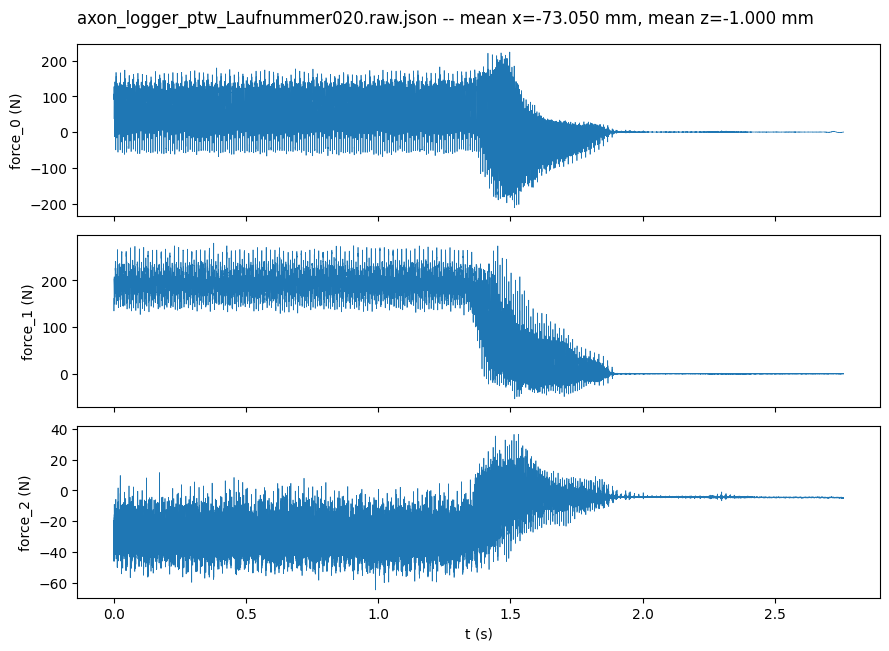

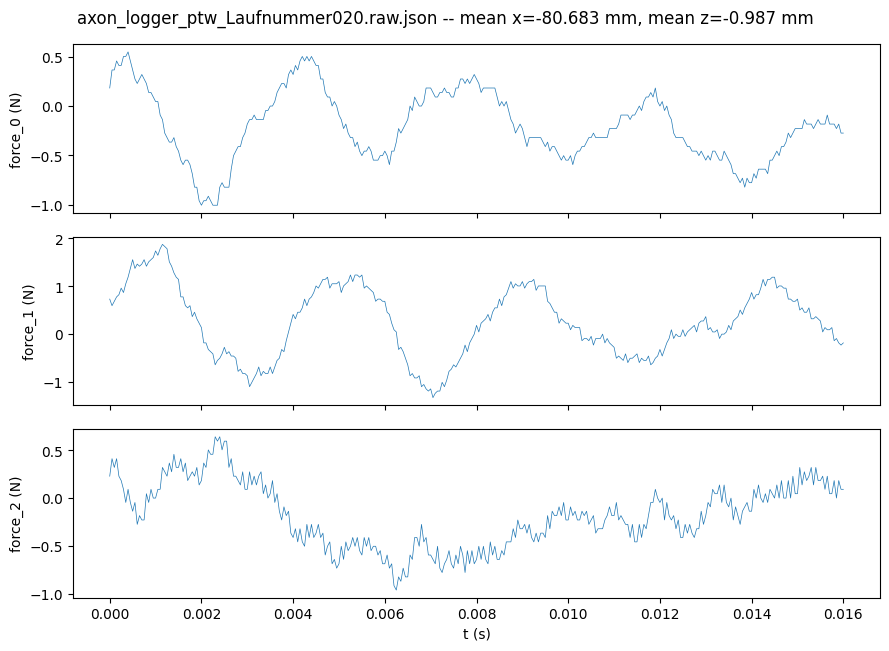

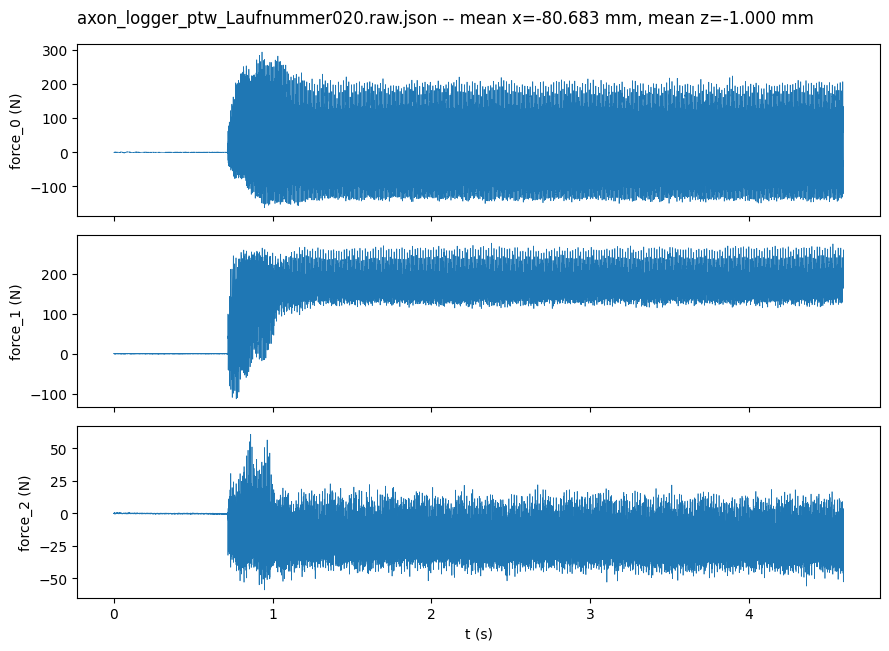

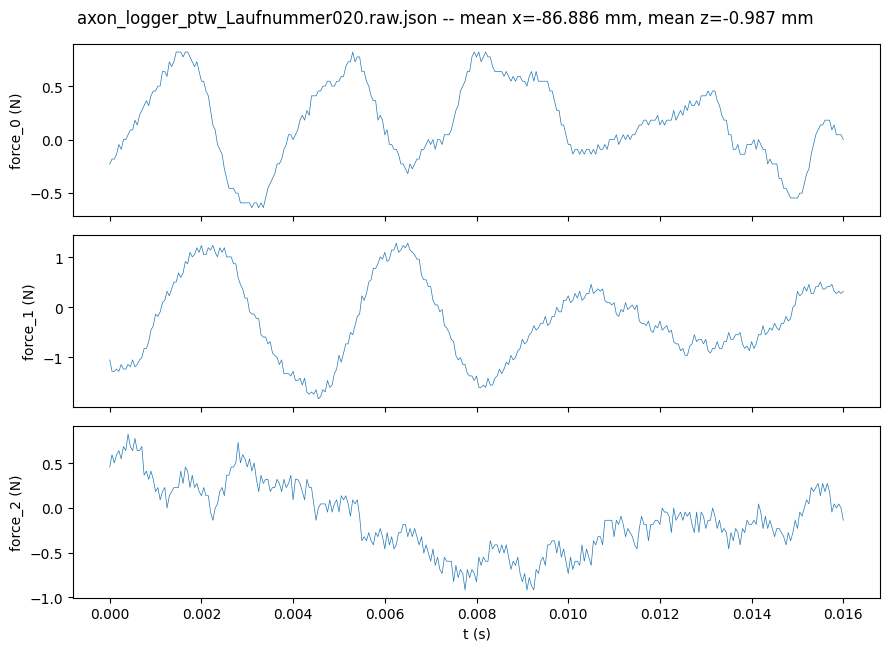

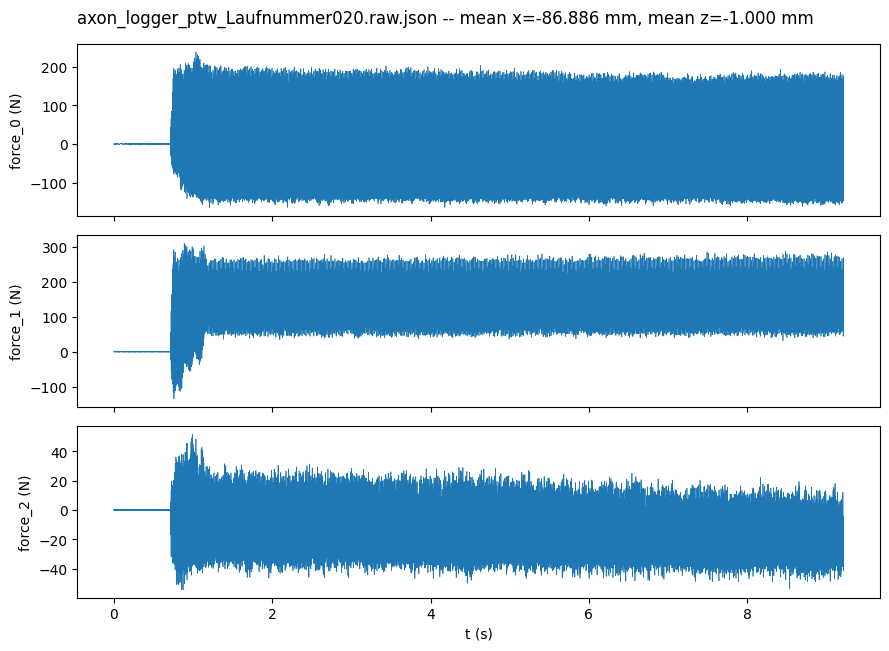

axon_logger_ptw_Laufnummer020.raw.json: 3 Eingriffs-Segmente (Z < -0.5 mm), 5 stabile Teilsegmente (dX < 0.01 mm, dZ < 0.01 mm) geplottet und als CSV exportiert.


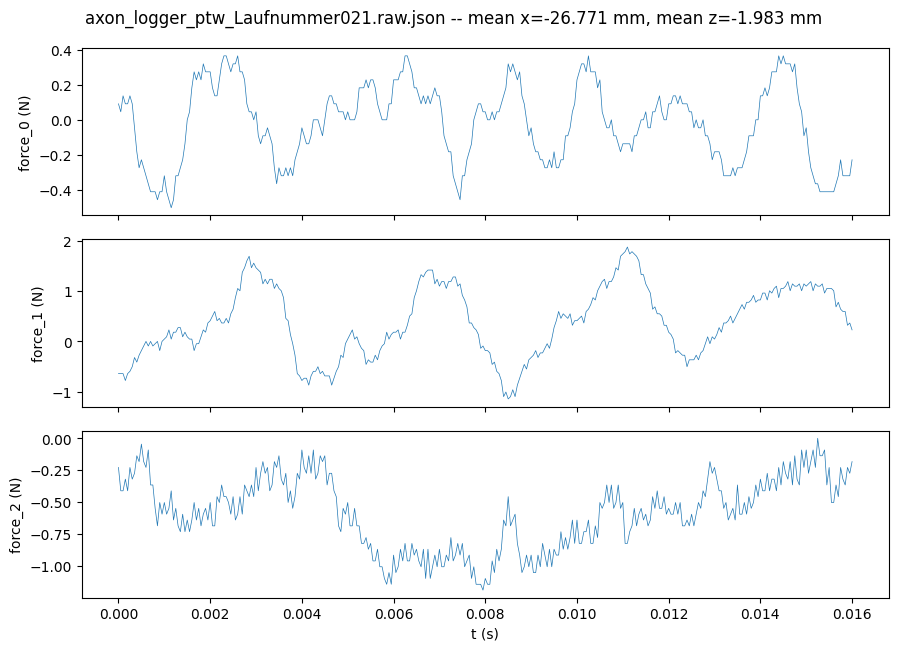

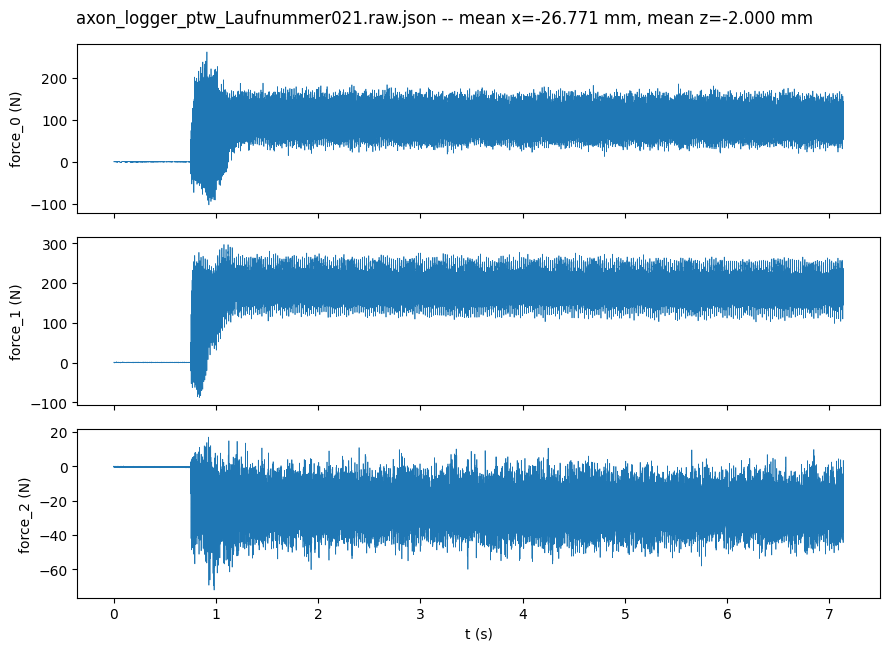

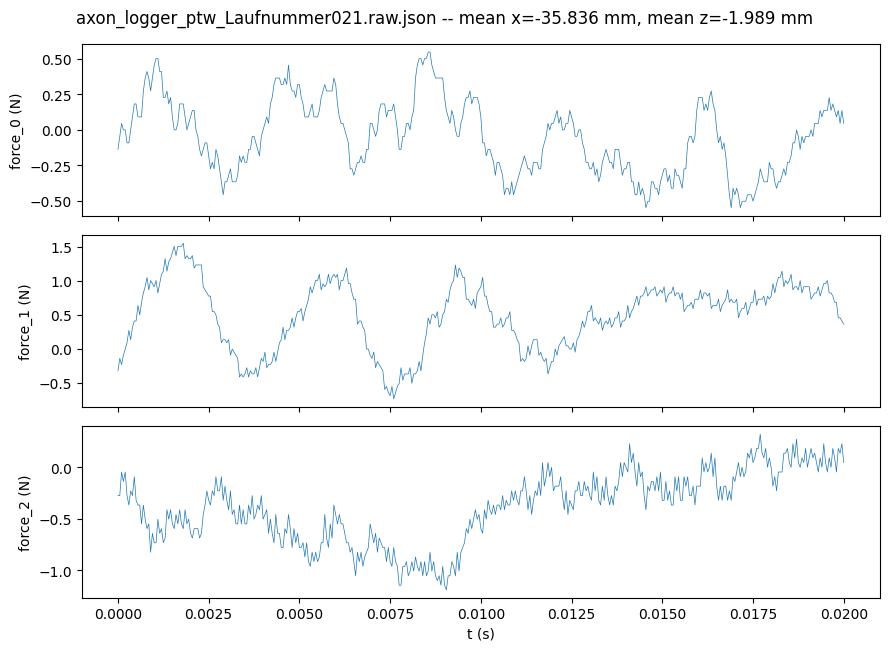

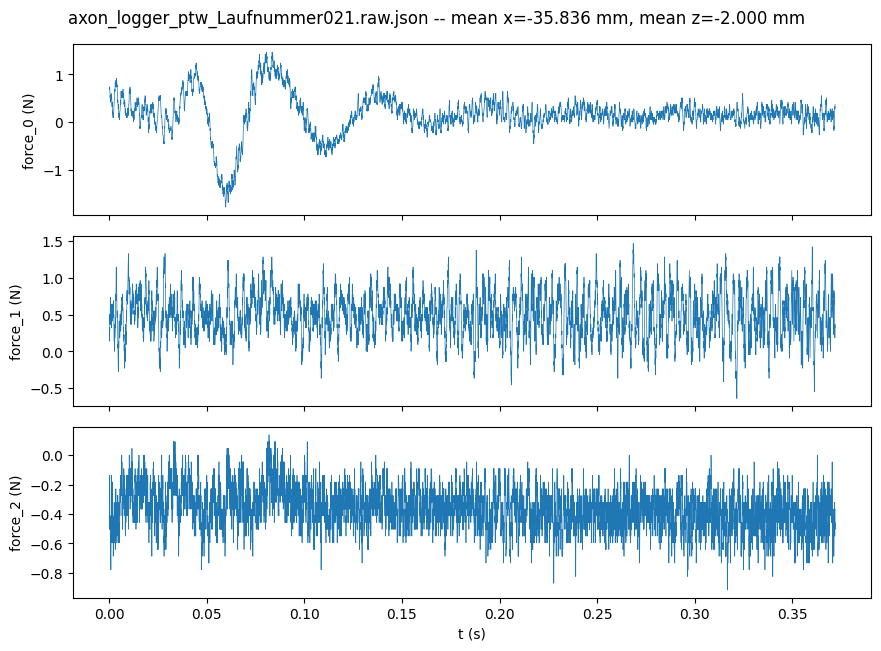

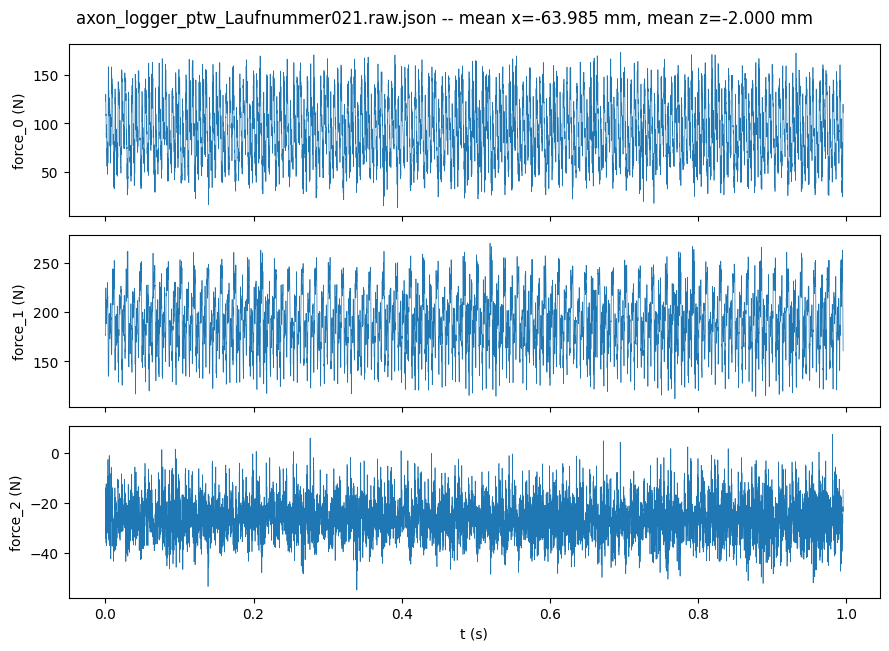

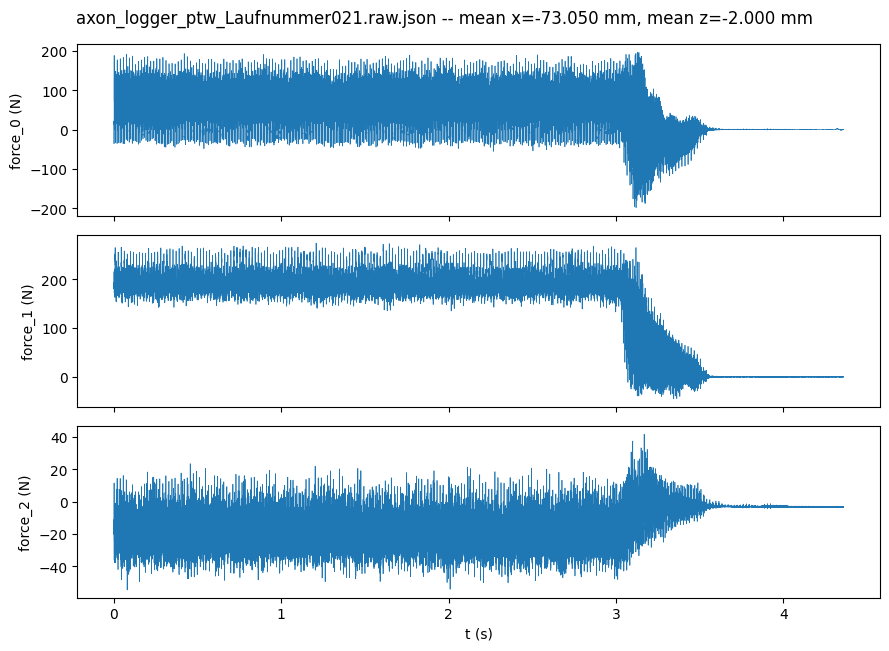

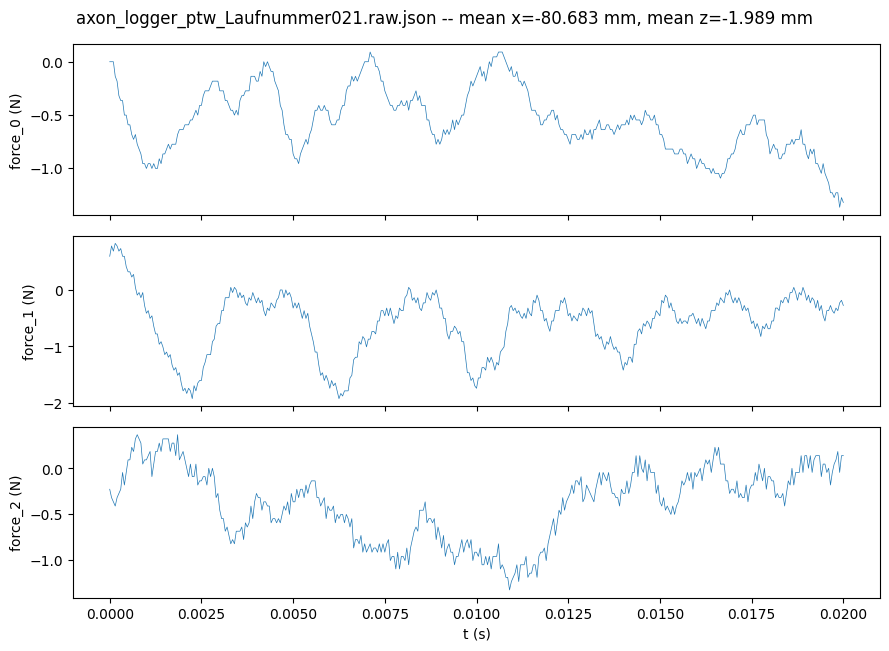

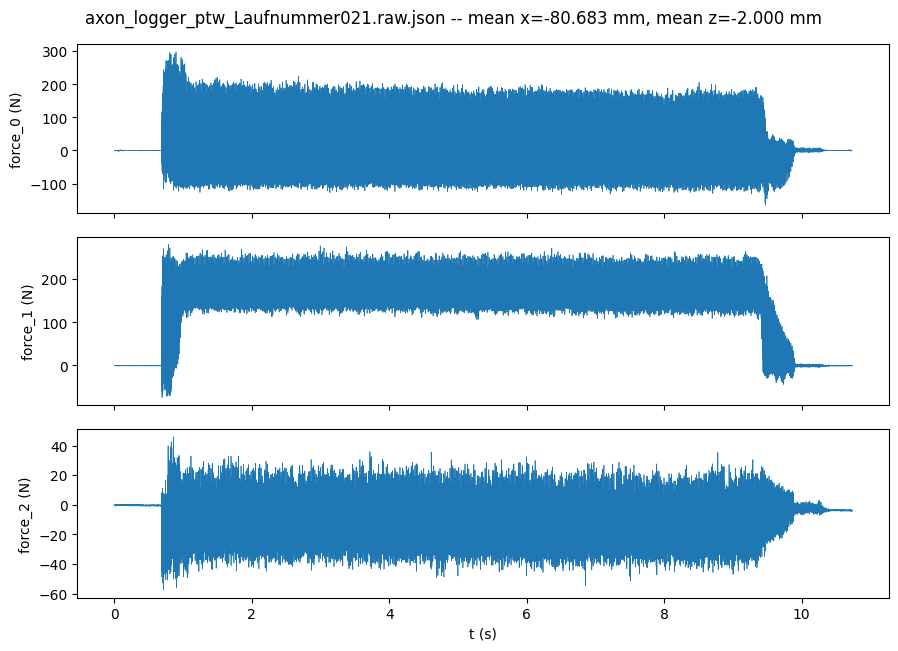

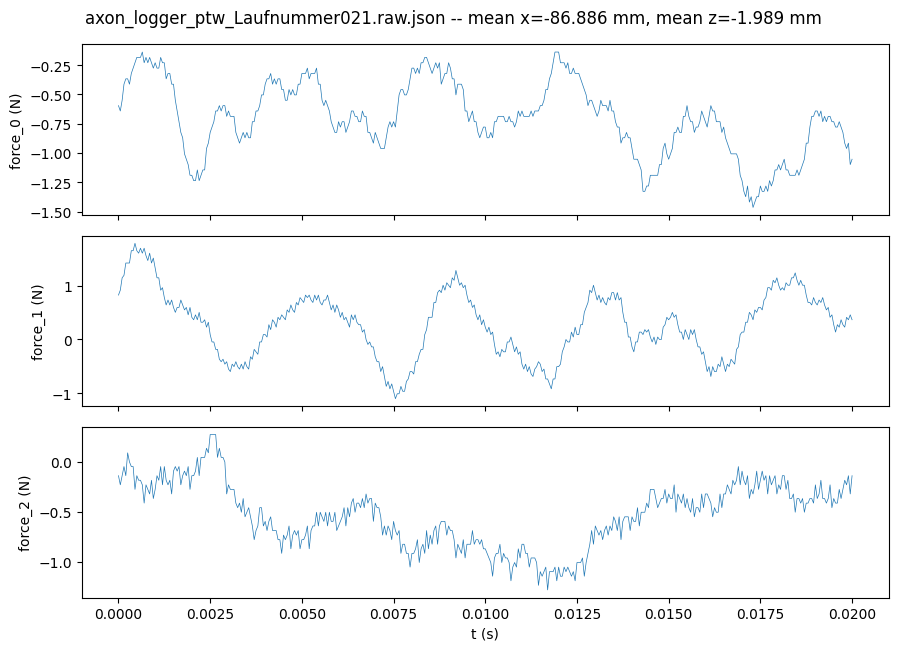

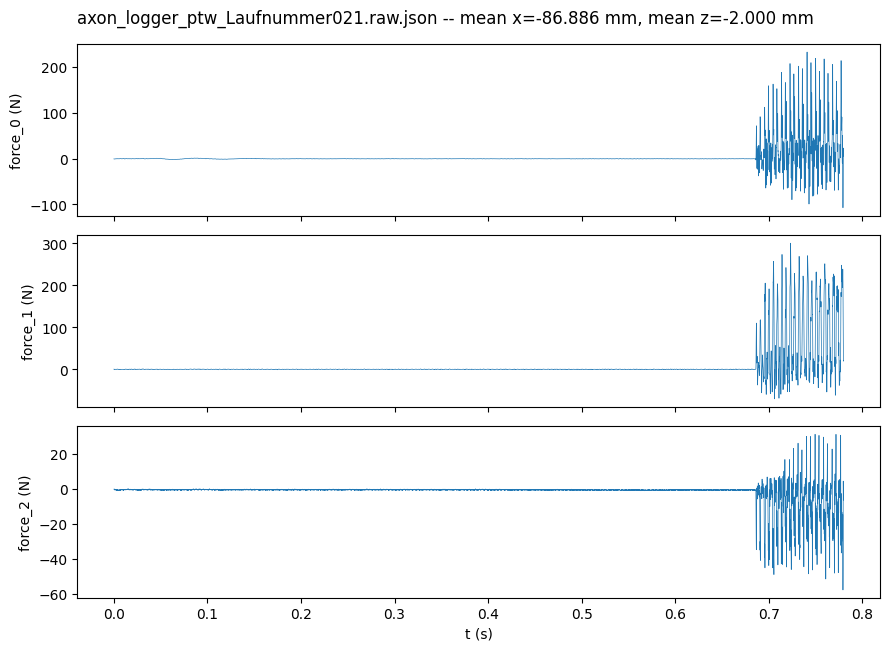

axon_logger_ptw_Laufnummer021.raw.json: 5 Eingriffs-Segmente (Z < -0.5 mm), 10 stabile Teilsegmente (dX < 0.01 mm, dZ < 0.01 mm) geplottet und als CSV exportiert.


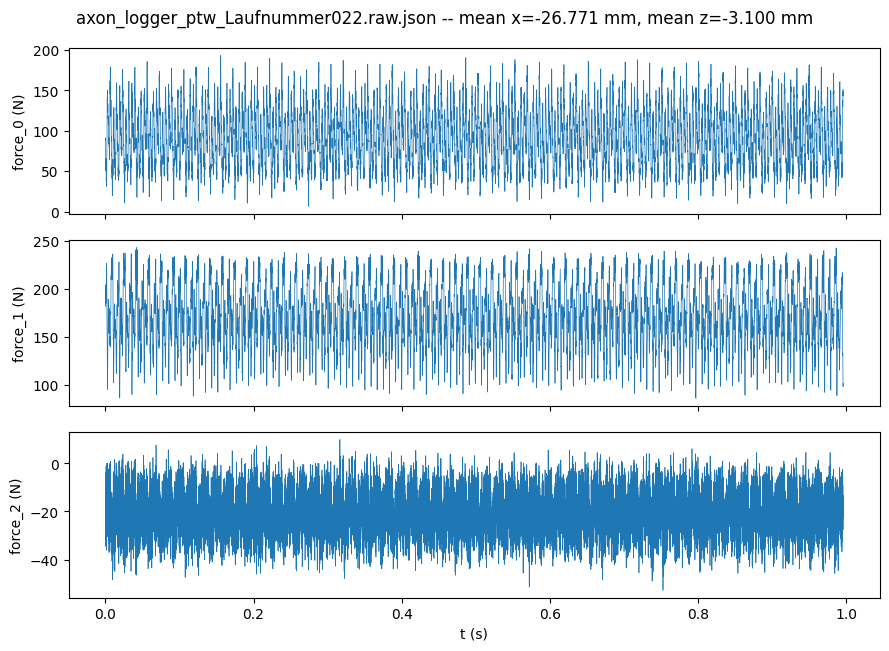

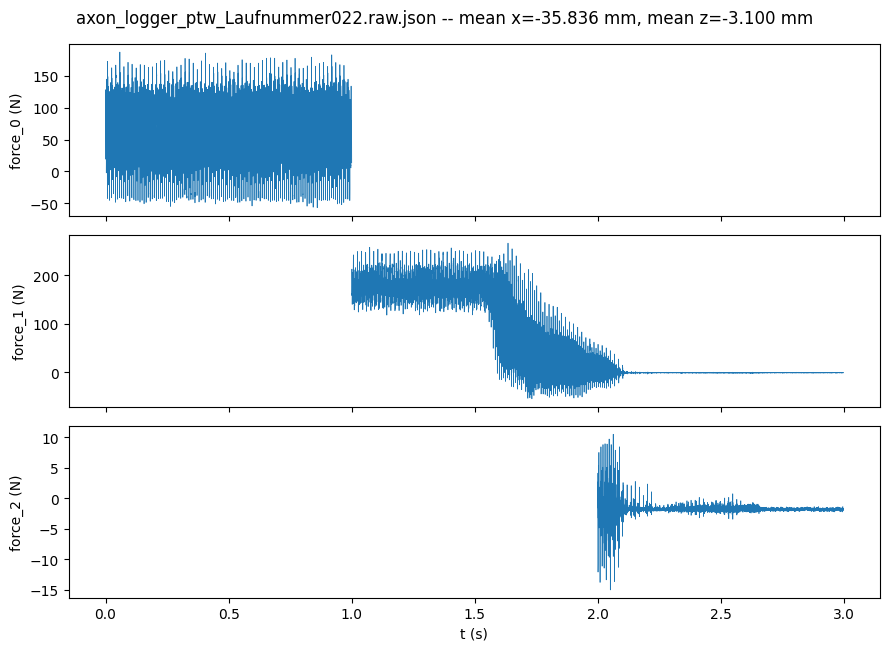

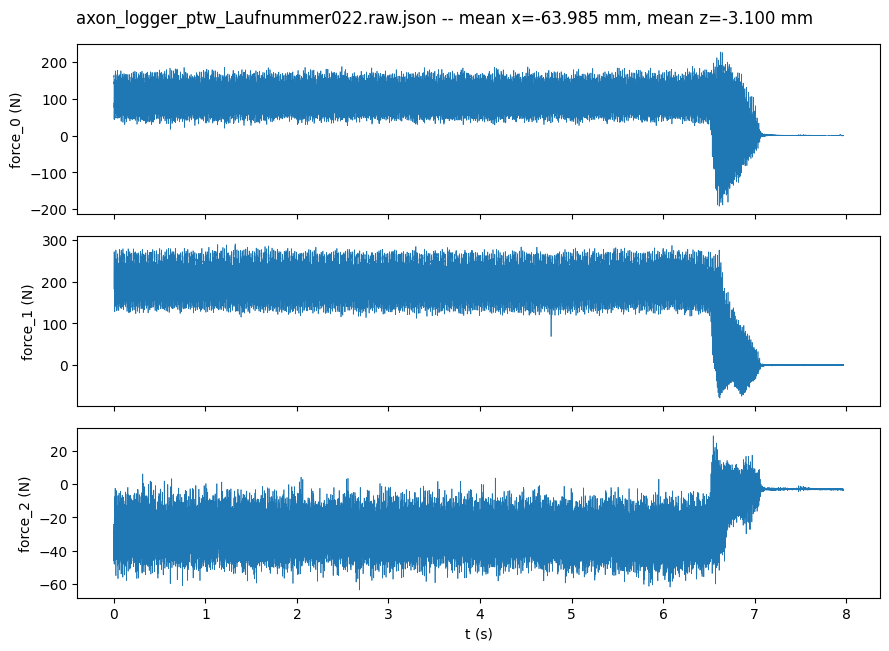

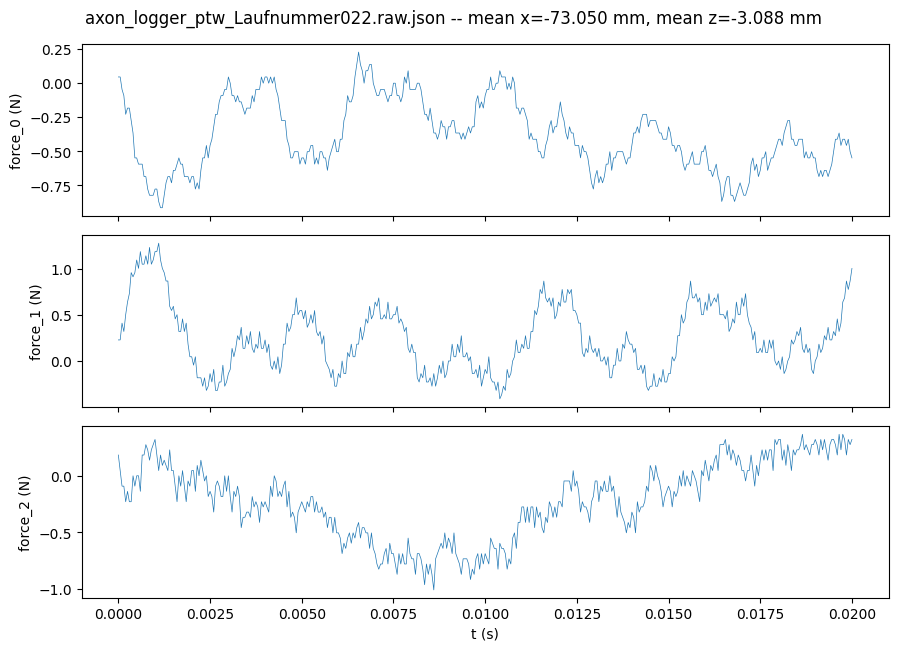

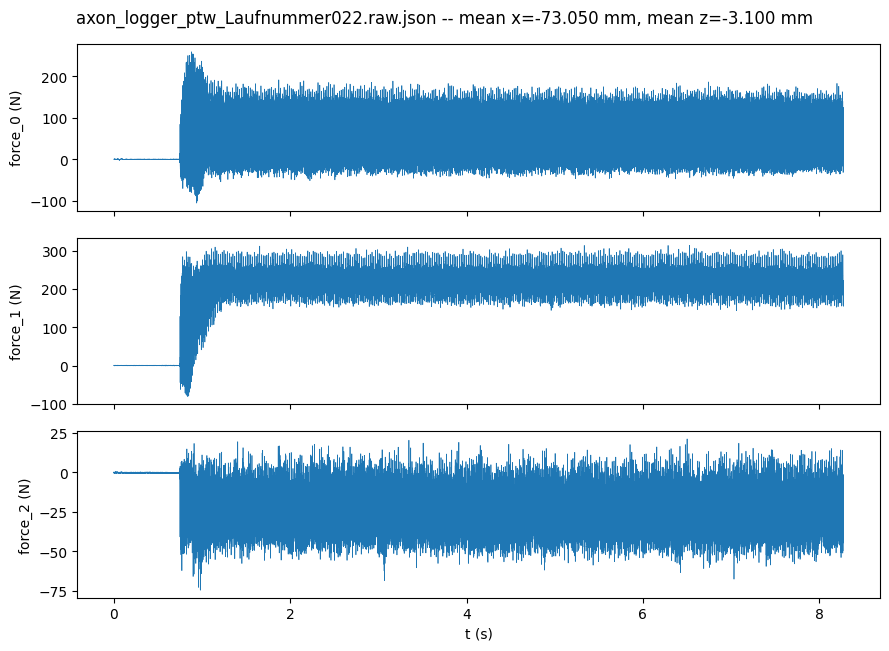

axon_logger_ptw_Laufnummer022.raw.json: 3 Eingriffs-Segmente (Z < -0.5 mm), 5 stabile Teilsegmente (dX < 0.01 mm, dZ < 0.01 mm) geplottet und als CSV exportiert.


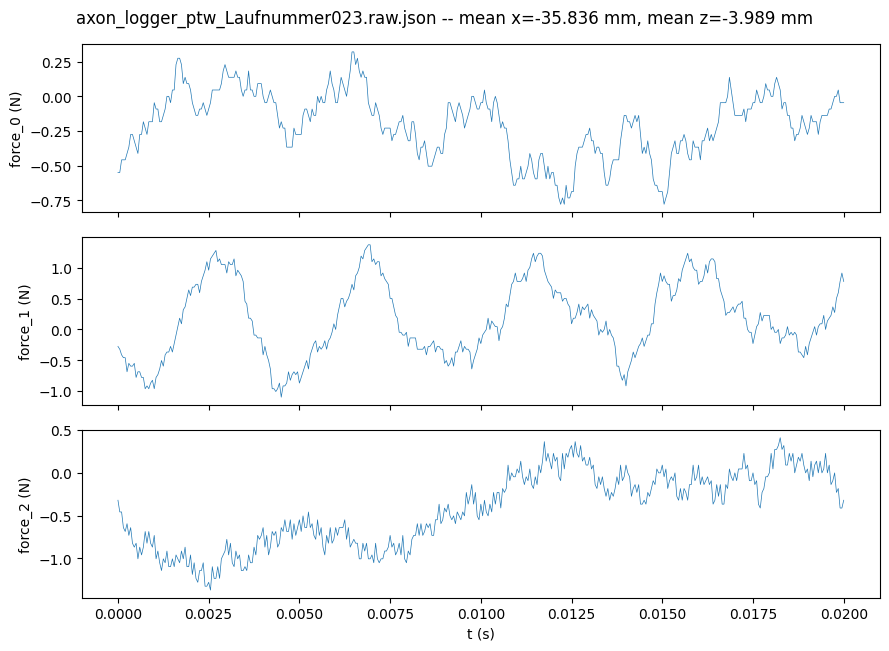

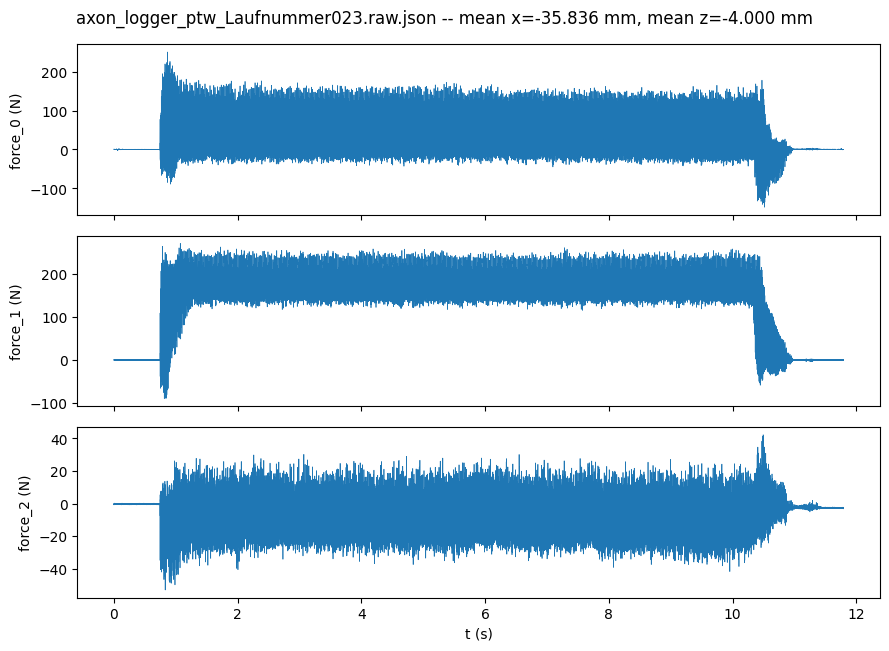

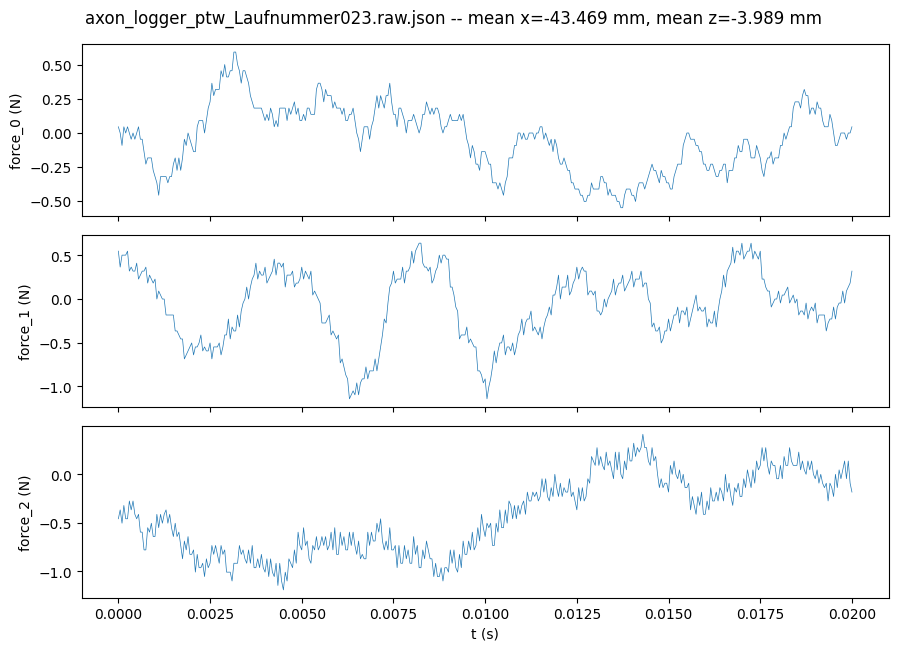

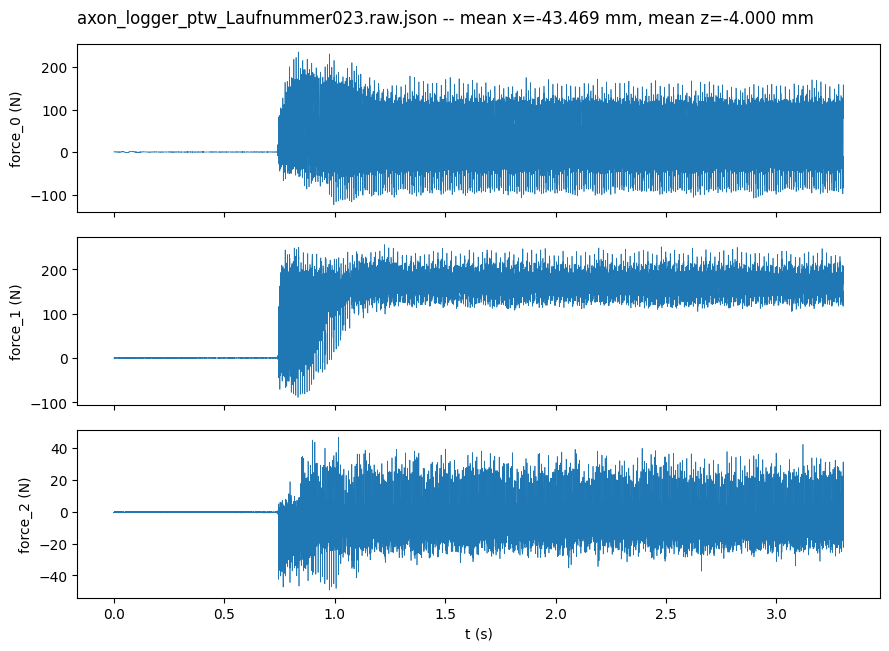

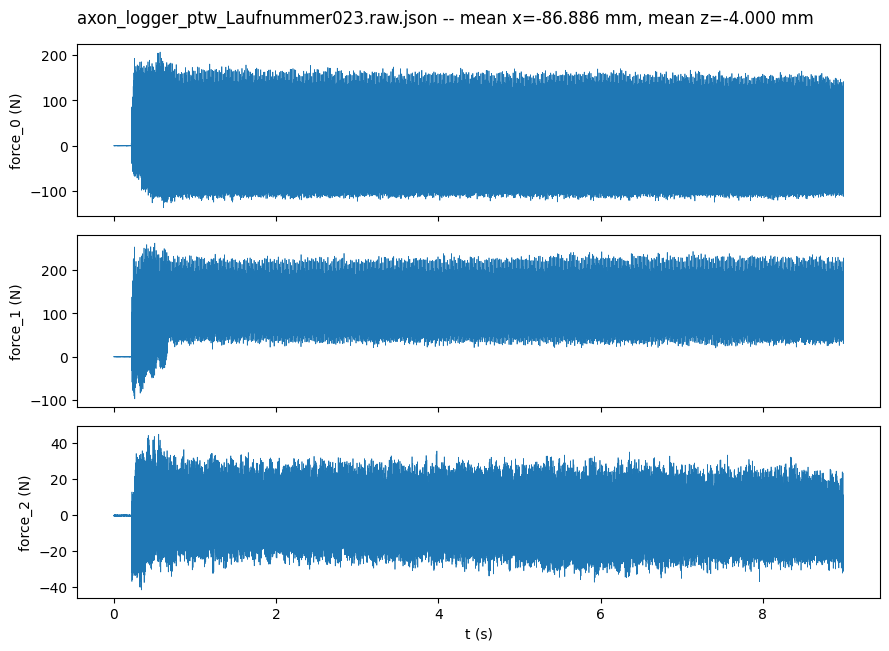

axon_logger_ptw_Laufnummer023.raw.json: 2 Eingriffs-Segmente (Z < -0.5 mm), 5 stabile Teilsegmente (dX < 0.01 mm, dZ < 0.01 mm) geplottet und als CSV exportiert.


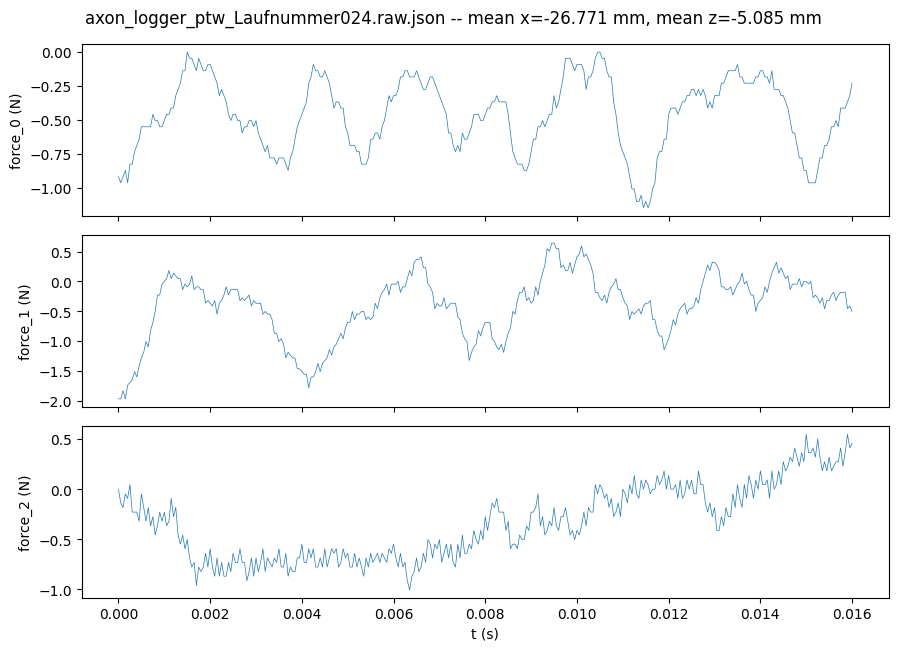

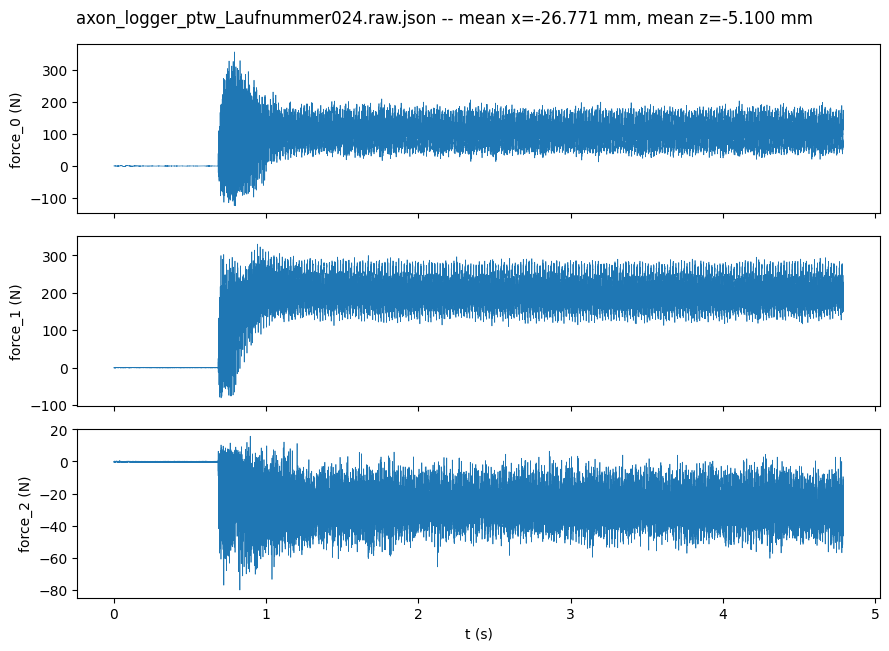

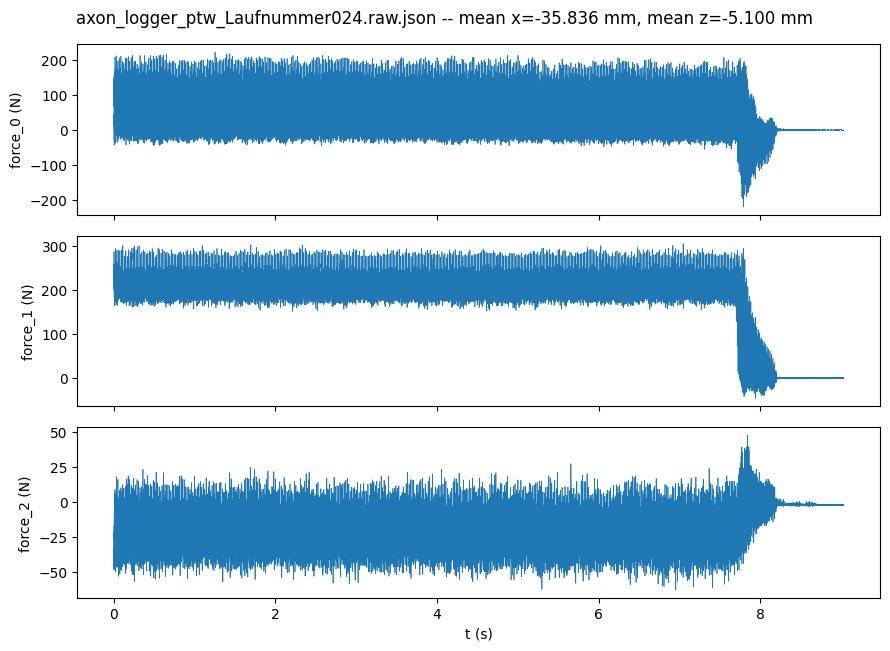

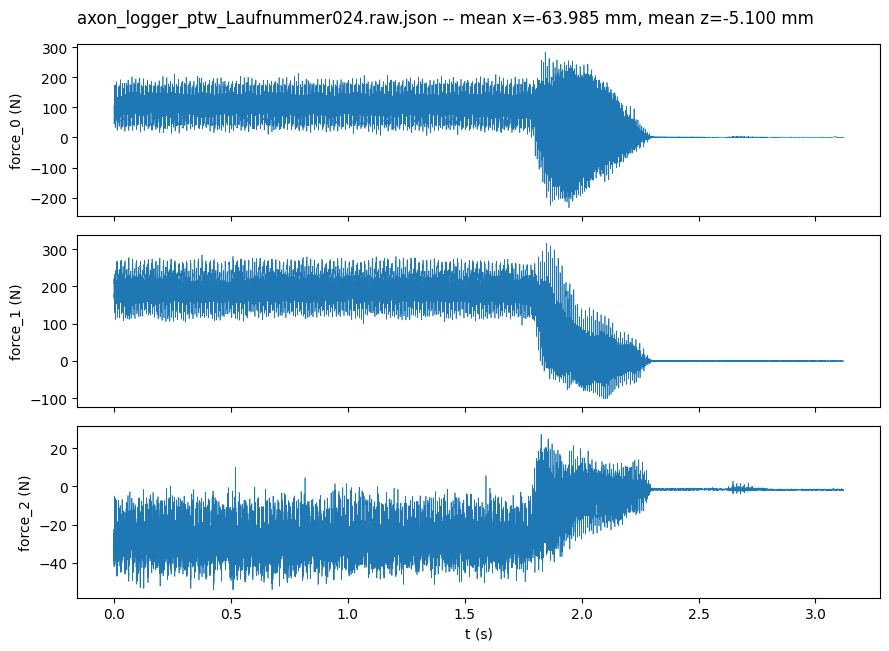

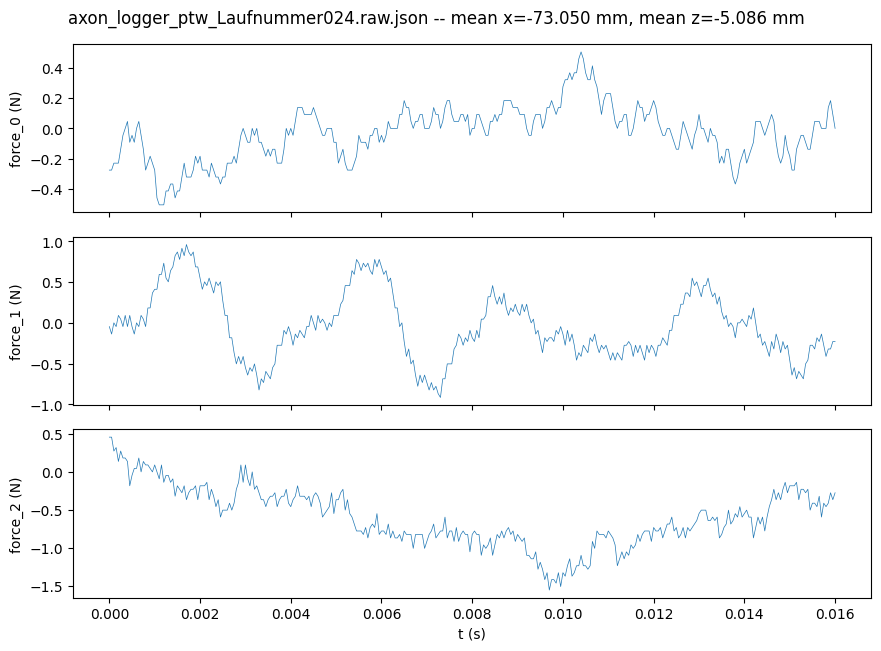

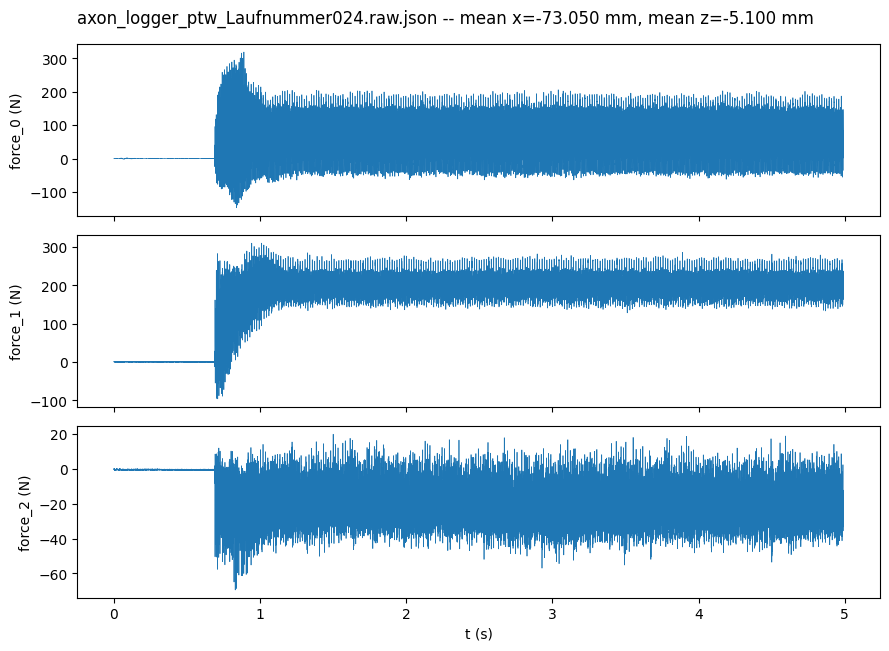

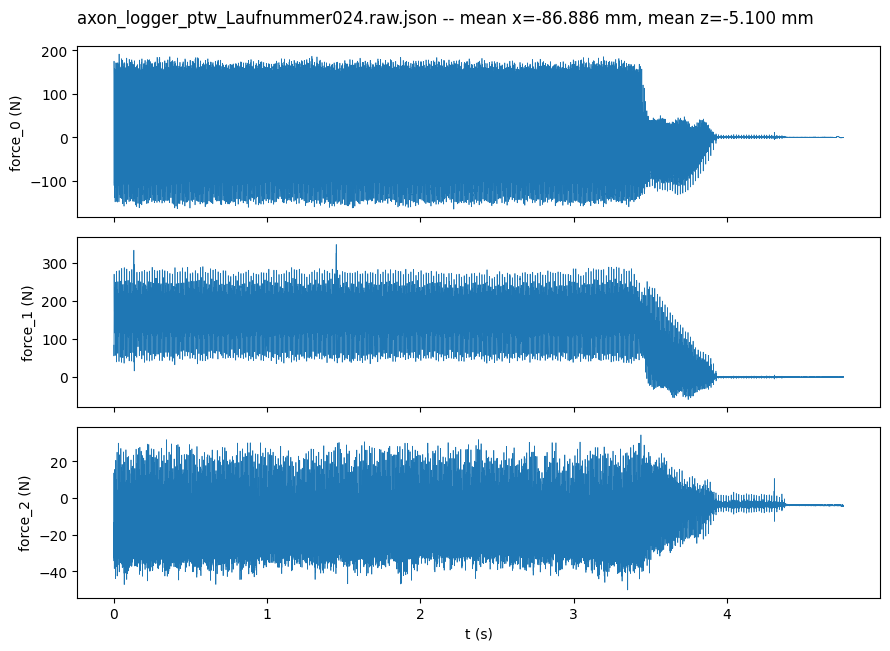

axon_logger_ptw_Laufnummer024.raw.json: 3 Eingriffs-Segmente (Z < -0.5 mm), 7 stabile Teilsegmente (dX < 0.01 mm, dZ < 0.01 mm) geplottet und als CSV exportiert.


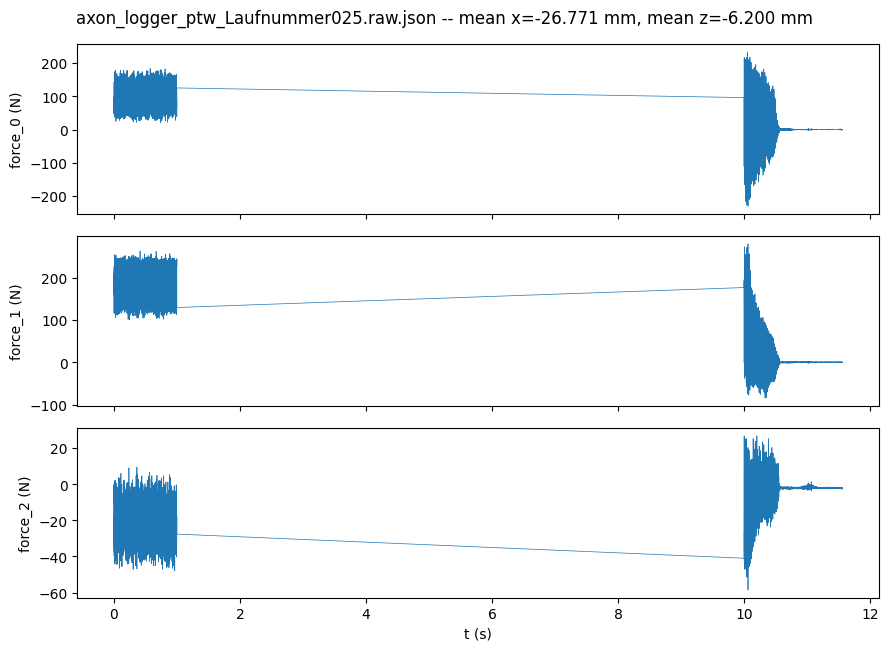

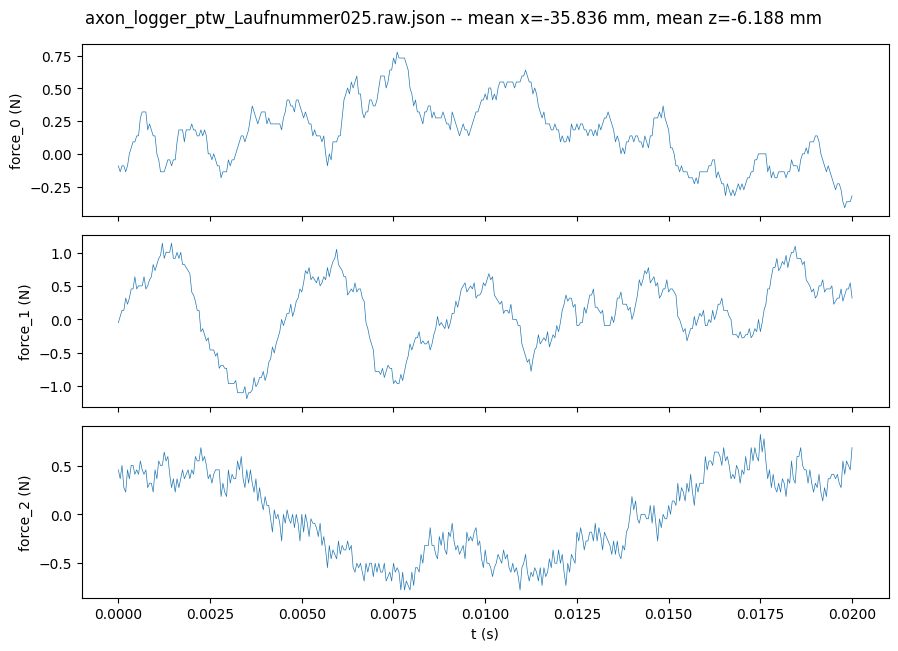

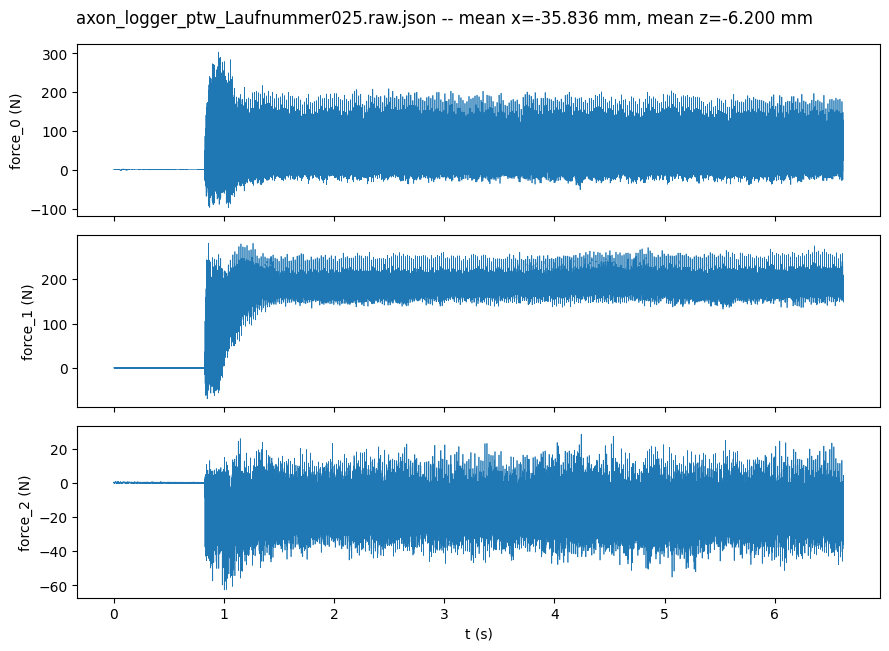

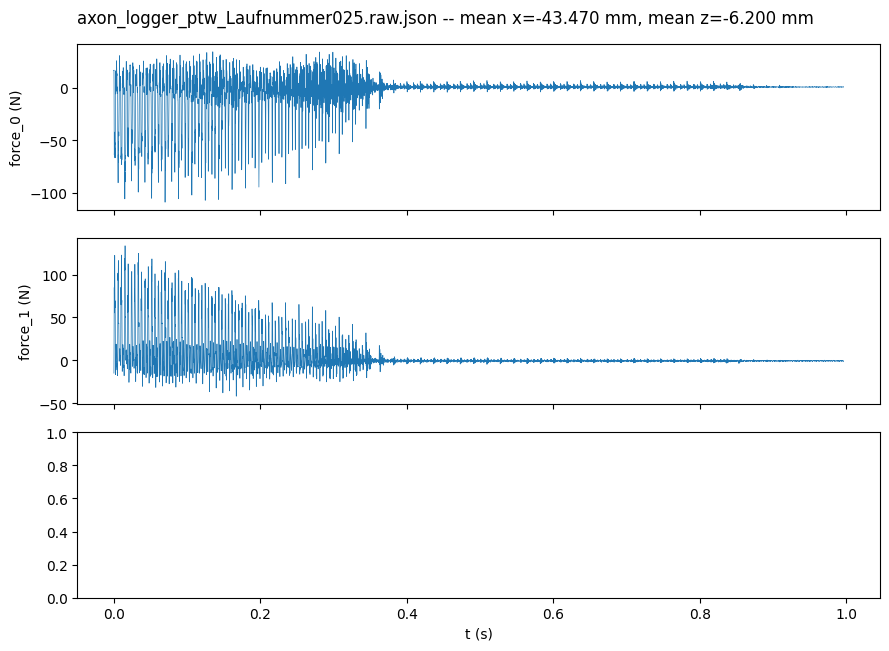

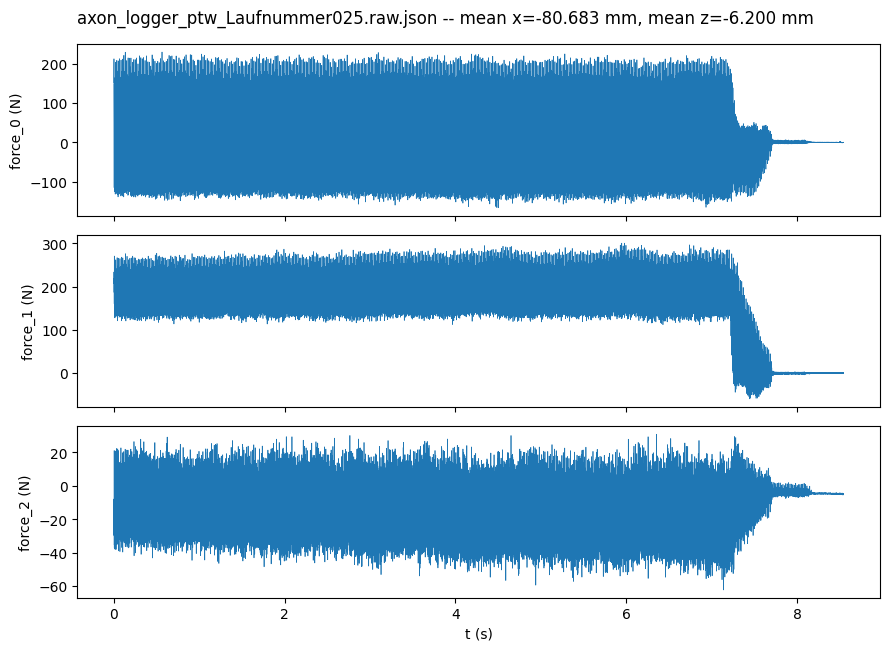

axon_logger_ptw_Laufnummer025.raw.json: 3 Eingriffs-Segmente (Z < -0.5 mm), 5 stabile Teilsegmente (dX < 0.01 mm, dZ < 0.01 mm) geplottet und als CSV exportiert.


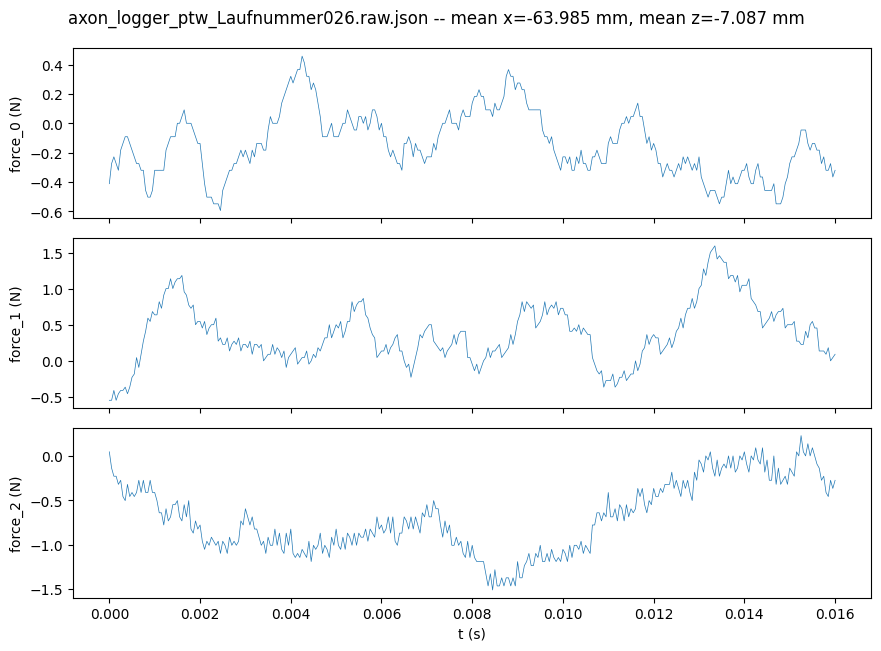

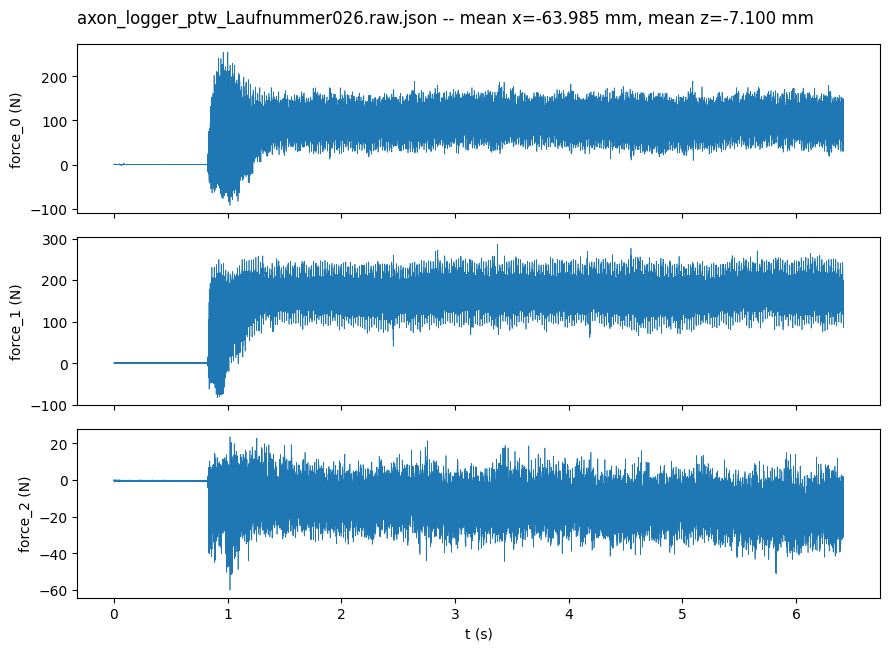

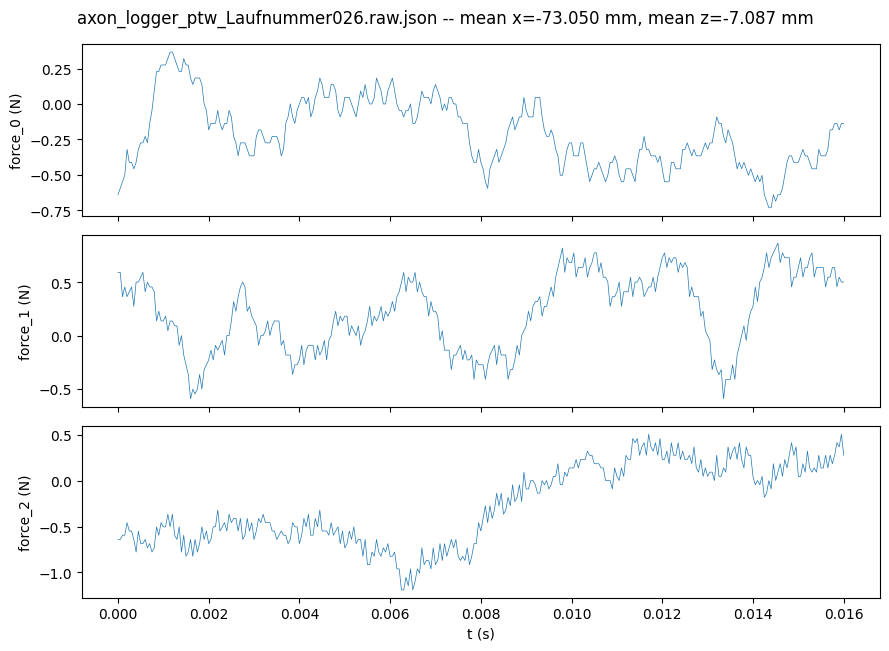

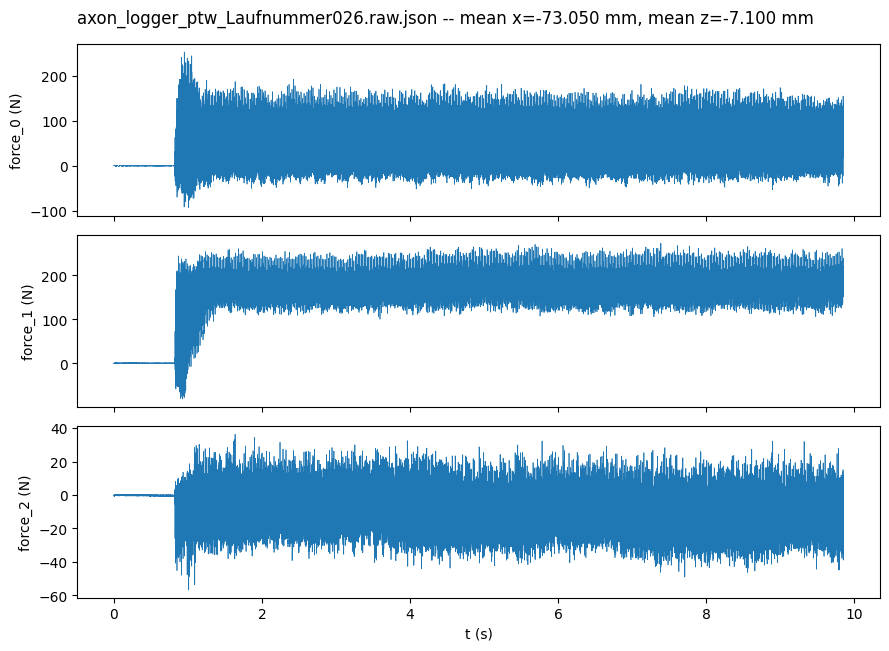

axon_logger_ptw_Laufnummer026.raw.json: 2 Eingriffs-Segmente (Z < -0.5 mm), 4 stabile Teilsegmente (dX < 0.01 mm, dZ < 0.01 mm) geplottet und als CSV exportiert.


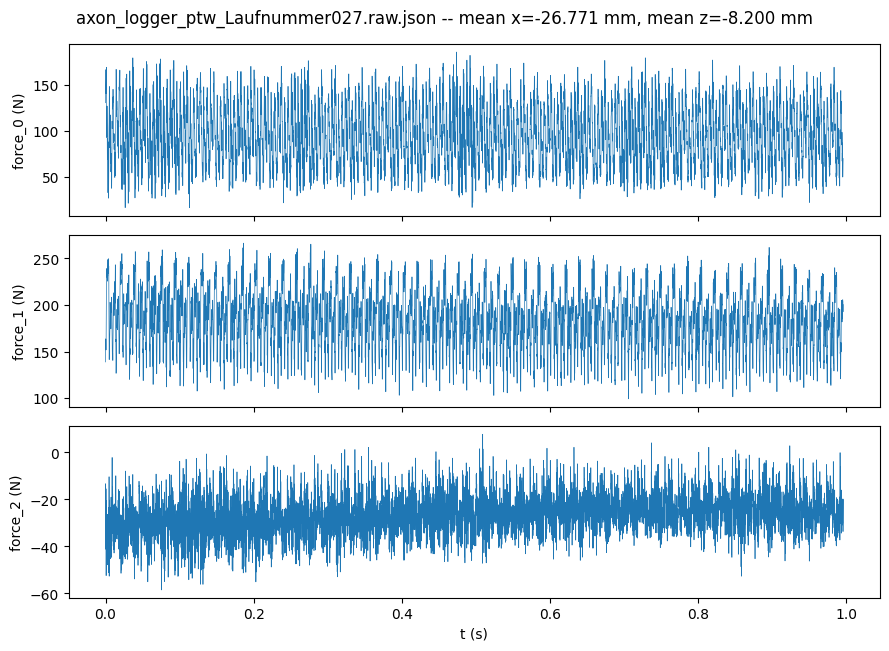

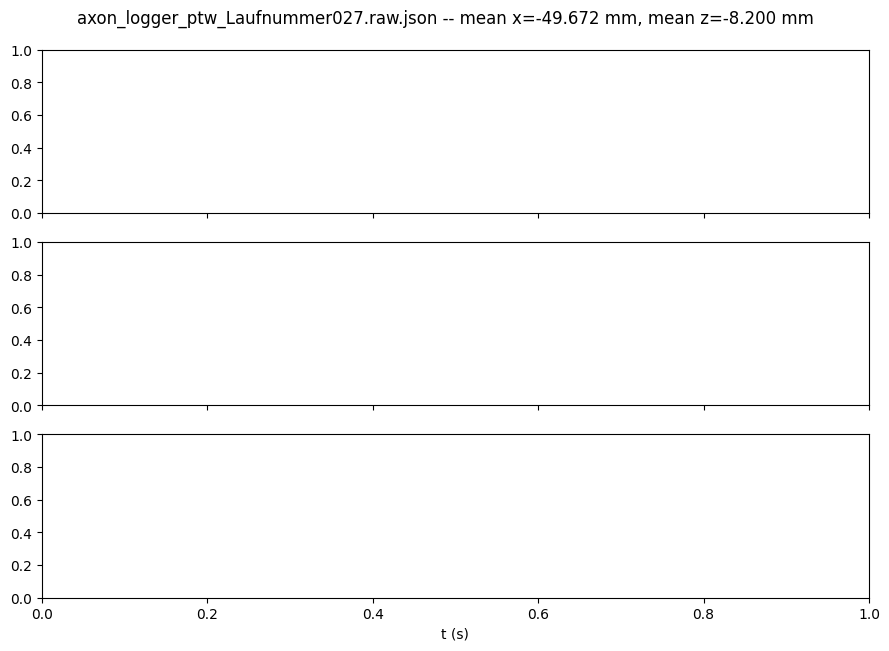

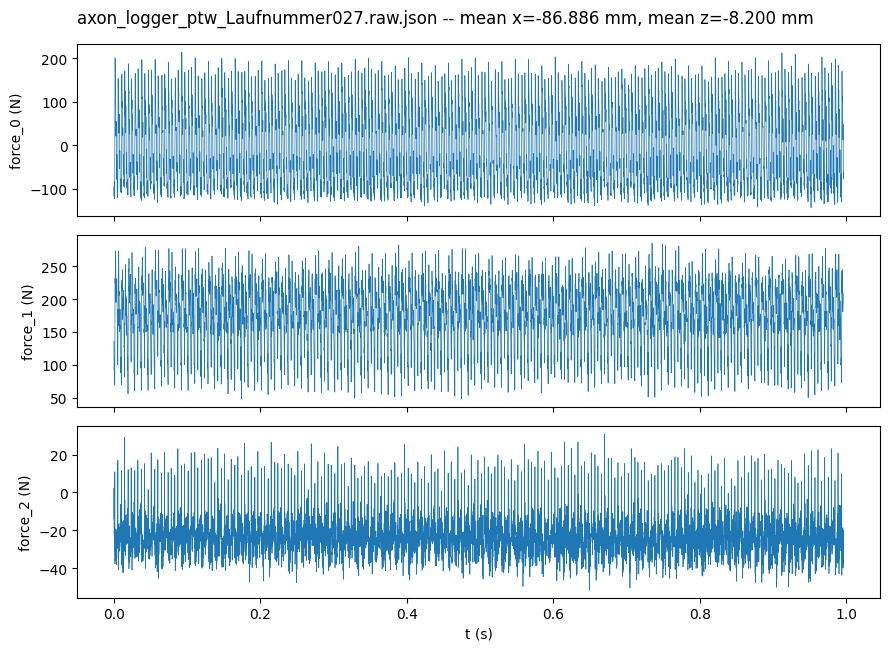

axon_logger_ptw_Laufnummer027.raw.json: 2 Eingriffs-Segmente (Z < -0.5 mm), 3 stabile Teilsegmente (dX < 0.01 mm, dZ < 0.01 mm) geplottet und als CSV exportiert.


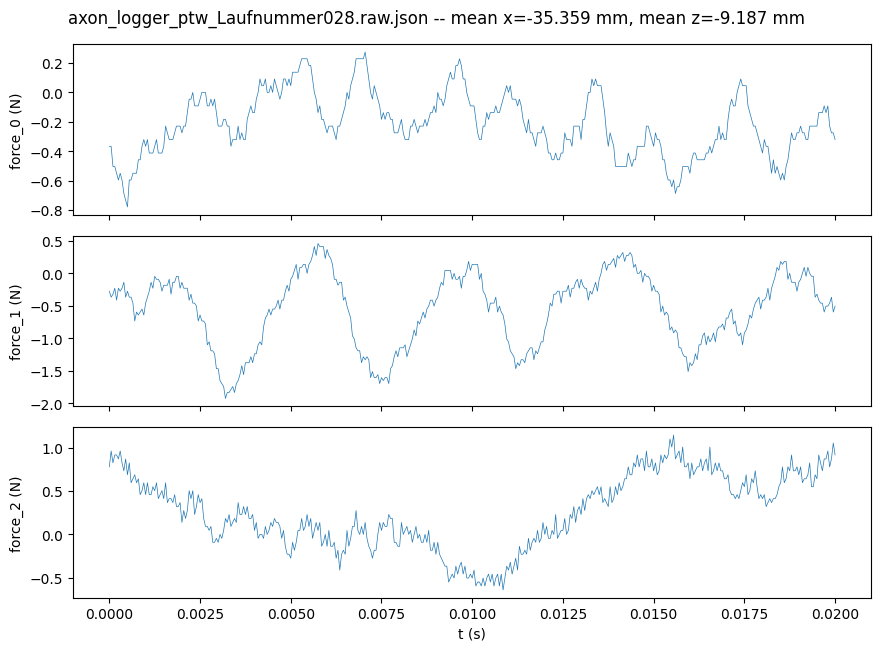

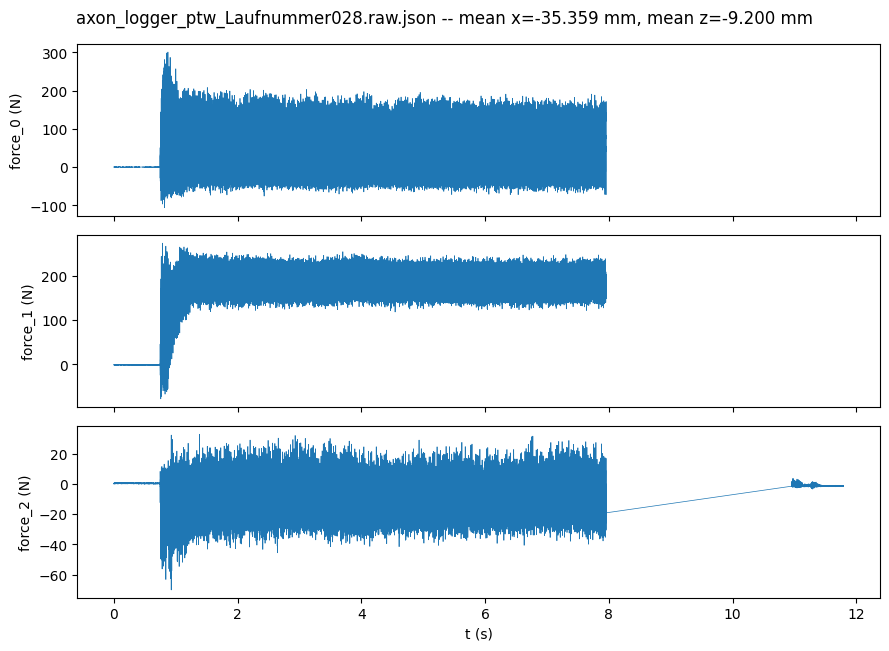

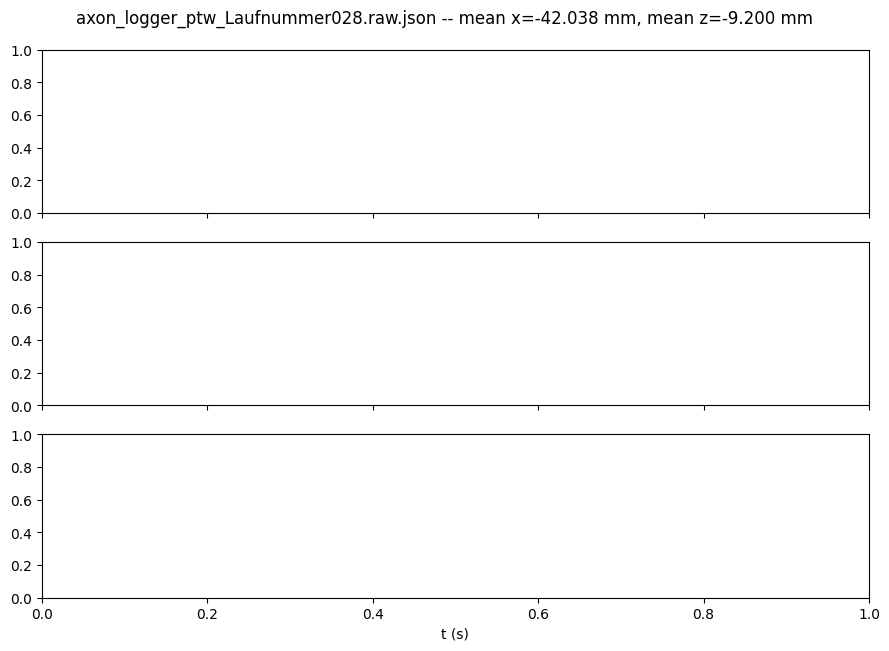

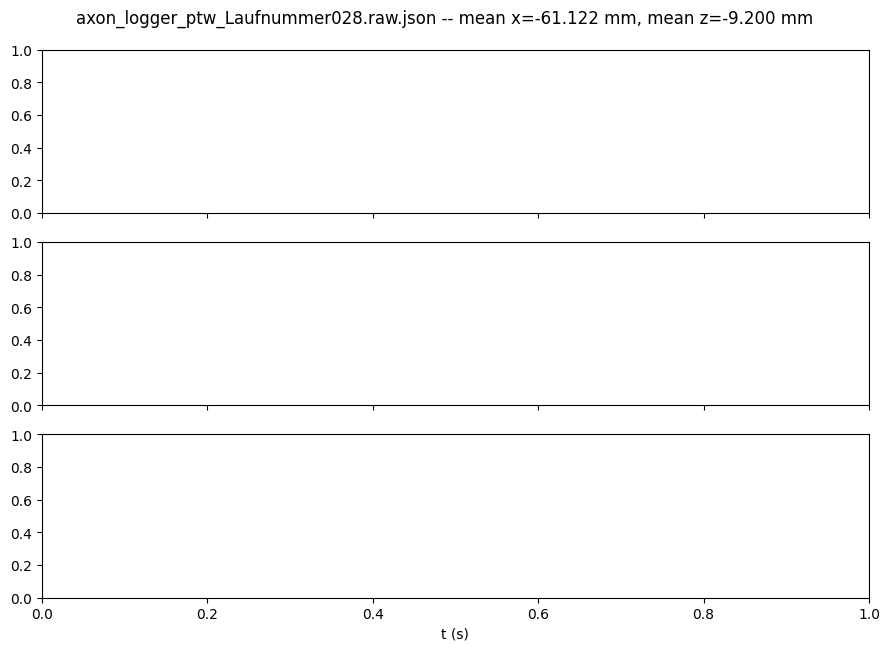

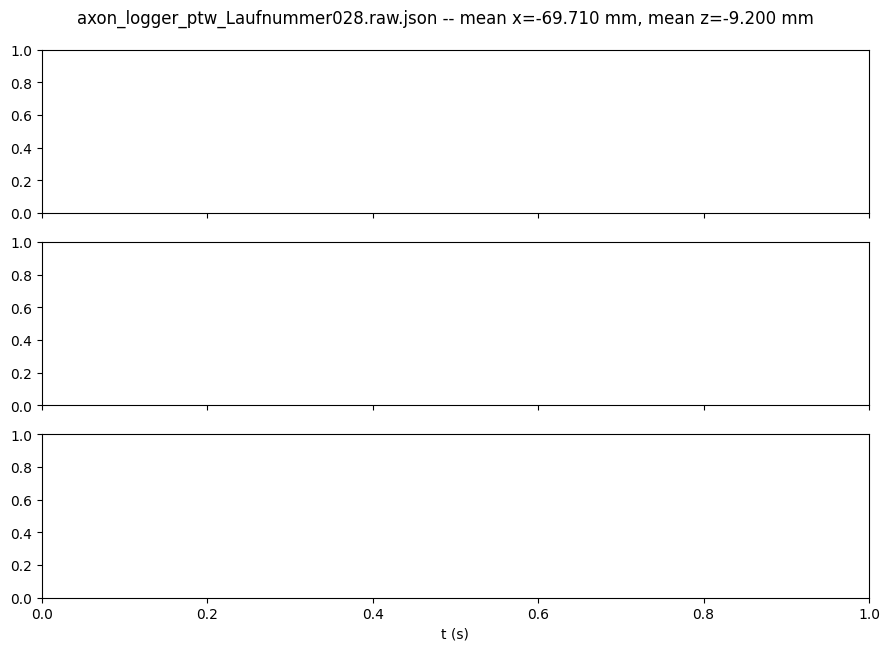

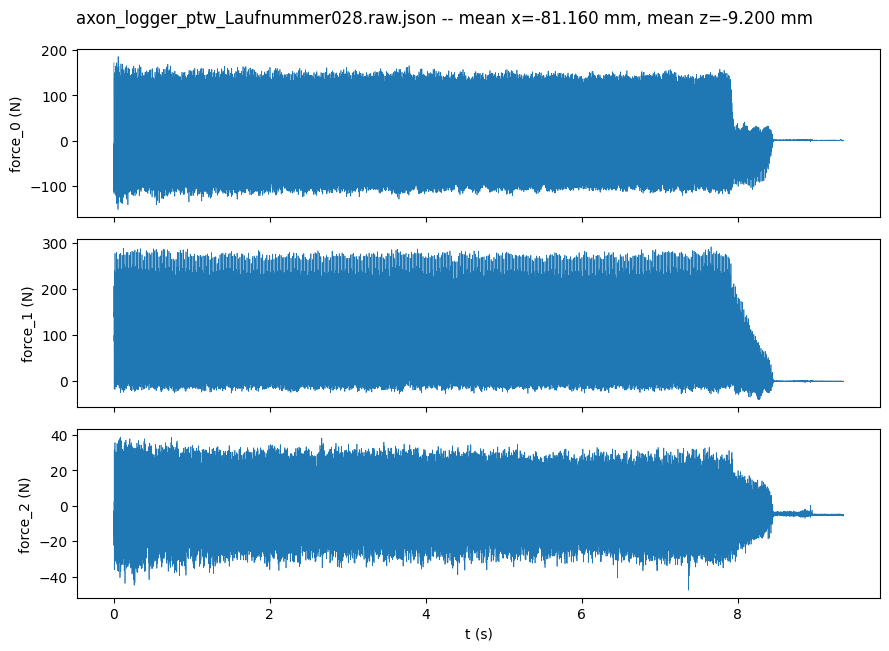

axon_logger_ptw_Laufnummer028.raw.json: 4 Eingriffs-Segmente (Z < -0.5 mm), 6 stabile Teilsegmente (dX < 0.01 mm, dZ < 0.01 mm) geplottet und als CSV exportiert.


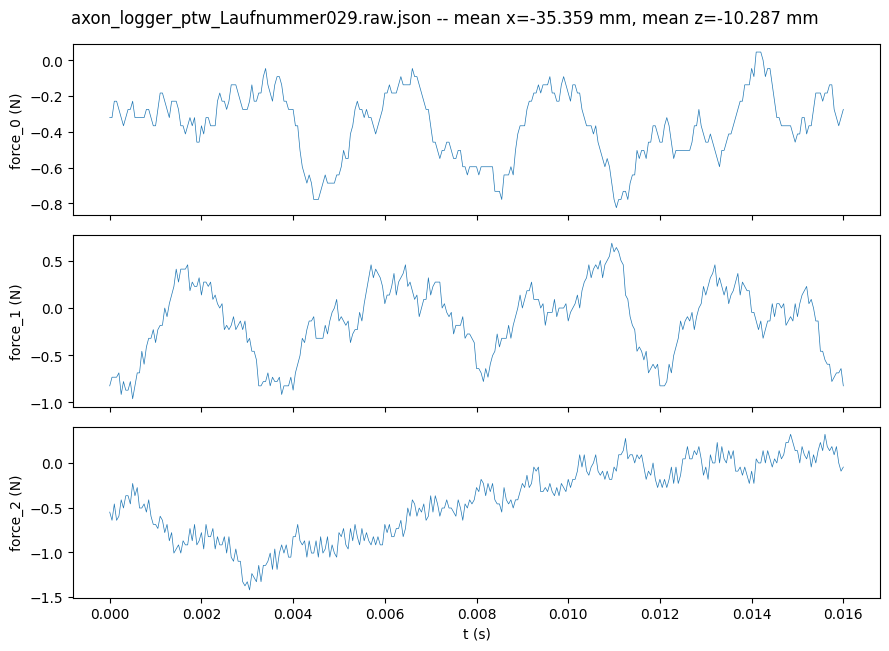

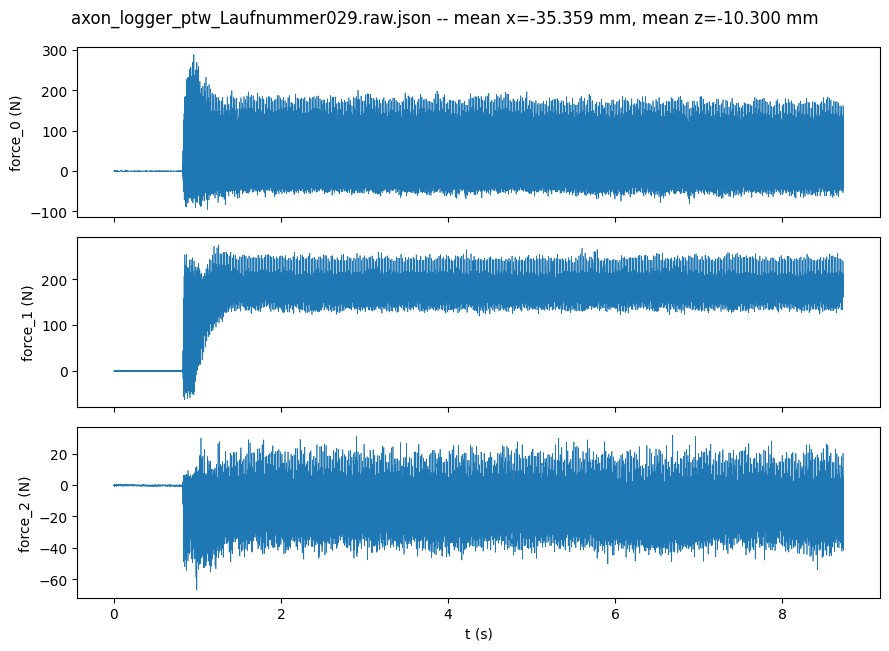

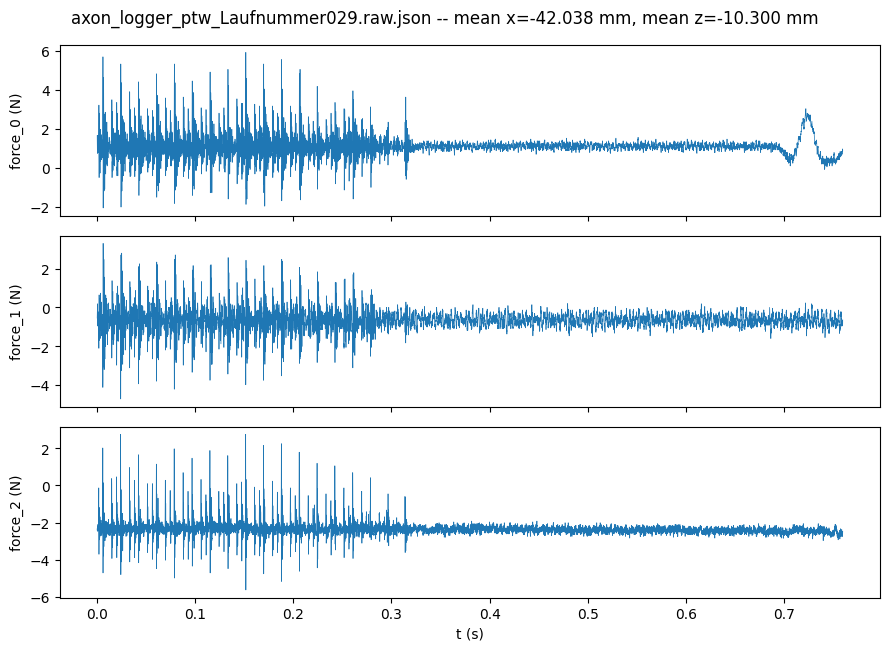

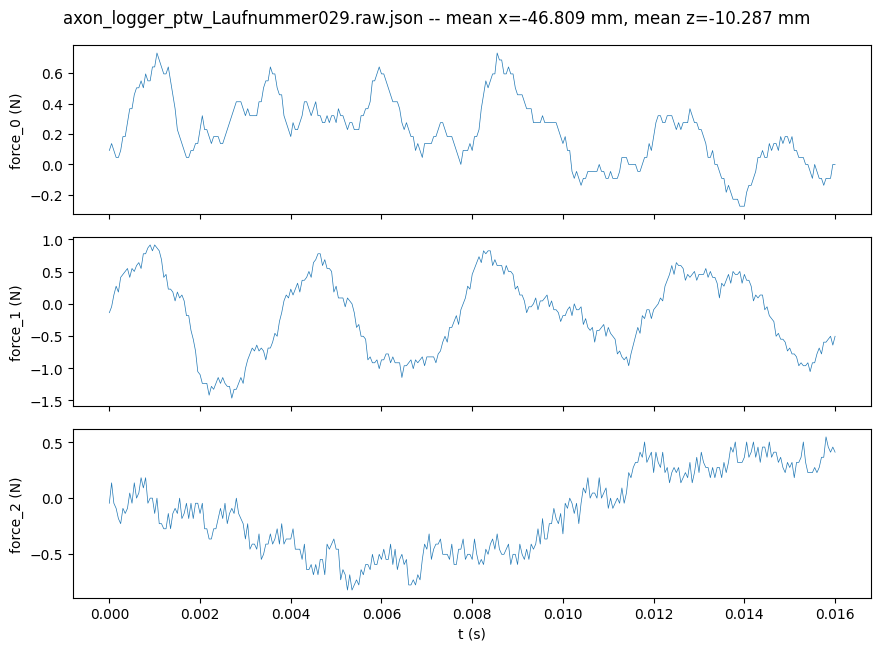

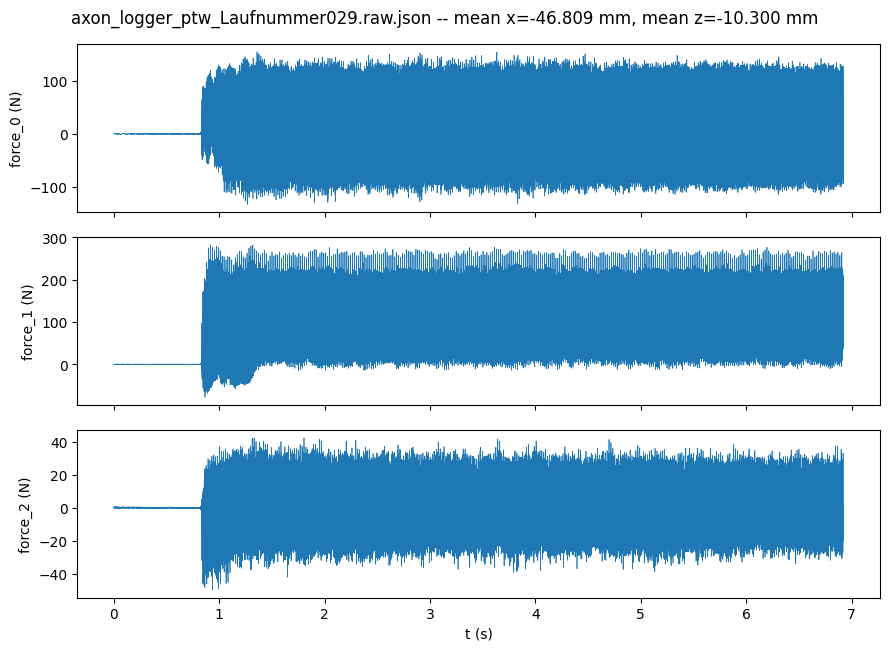

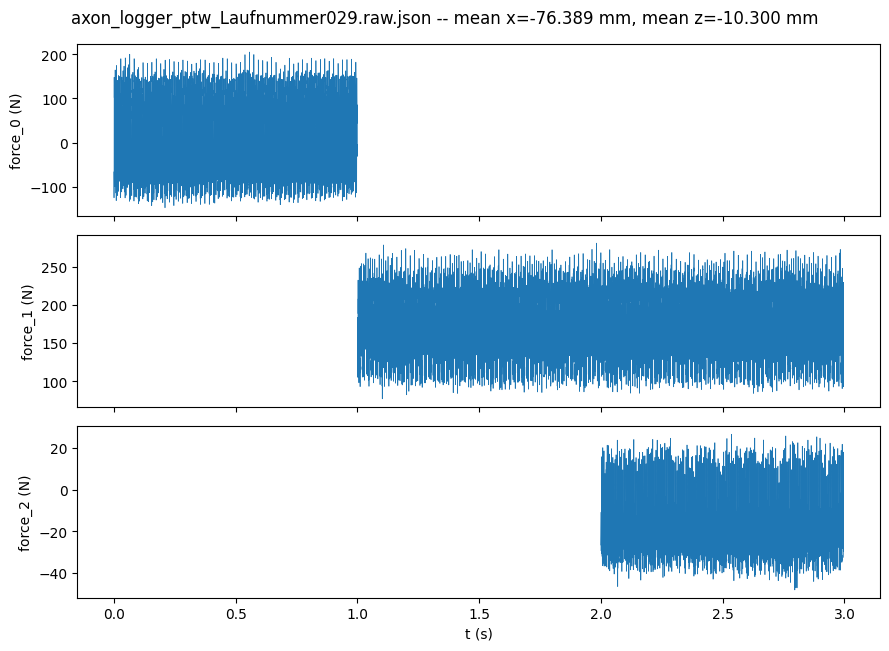

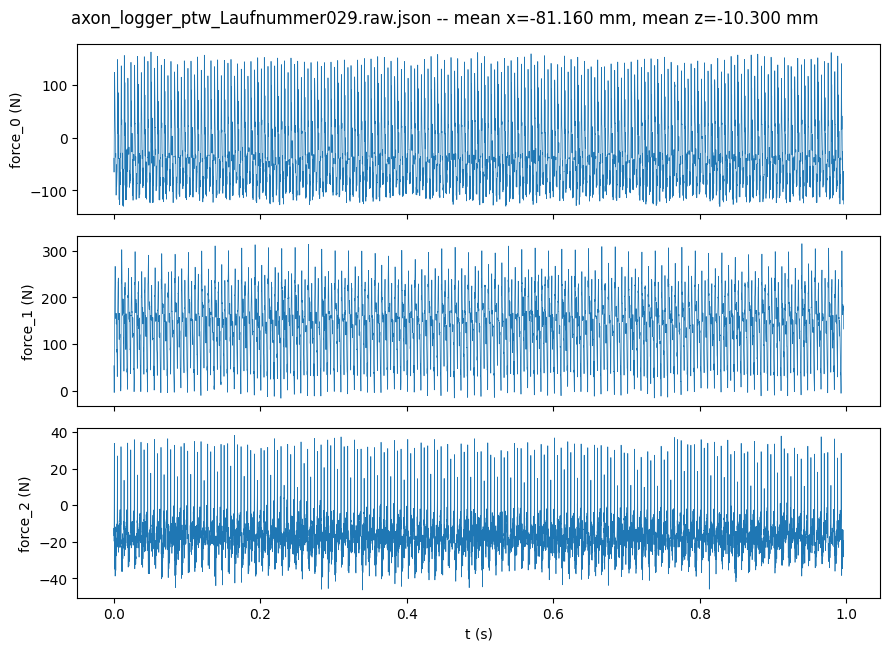

axon_logger_ptw_Laufnummer029.raw.json: 2 Eingriffs-Segmente (Z < -0.5 mm), 7 stabile Teilsegmente (dX < 0.01 mm, dZ < 0.01 mm) geplottet und als CSV exportiert.


In [1]:
# Nutzt die konsolidierten Utility-Funktionen aus cnc_cut_extractor.py (siehe dort fuer
# Docstrings/Details) statt eigener Kopien -- gemeinsamer Code fuer den separated_by_ln-Workflow.
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "../py")  # cnc_cut_extractor.py liegt in py/src
from src.cnc_cut_extractor import (
    load_axes_and_force, contiguous_true_runs, find_stable_subruns, build_segment_table,
)

MEASUREMENT = "20260701_C45_y"
Z_THRESHOLD = -0.5        # mm -- Werkzeug im Eingriff, wenn Z unterhalb dieser Schwelle liegt
X_DIFF_THRESHOLD = 0.01   # mm -- max. laufende X-Spannweite eines stabilen Nut-Teilsegments
Z_DIFF_THRESHOLD = 0.01   # mm -- max. laufende Z-Spannweite eines stabilen Nut-Teilsegments
MIN_SEGMENT_SAMPLES = 5   # Samples @ 250Hz -- kuerzere (Teil-)Segmente werden verworfen
MERGE_TOLERANCE_MS = 4    # Achse(250Hz)<->Kraft(20kHz)-Zuordnungstoleranz, wie in extract_cut()

CUTTING_SLOTS_DIR = Path(f"../data/Hermle/{MEASUREMENT}/schnitte_cutting_slots")

ln_files = sorted(Path(f"../data/Hermle/{MEASUREMENT}/separated_by_ln")
                   .glob("axon_logger_ptw_Laufnummer*.raw.json"))
print(f"{len(ln_files)} separated_by_ln-Dateien gefunden fuer {MEASUREMENT}.")

CUTTING_SLOTS_DIR.mkdir(parents=True, exist_ok=True)

for ln_path in ln_files:
    pos_df, force_series = load_axes_and_force(ln_path)  # axis0/4/5/6, Defaults siehe cnc_cut_extractor.py
    if pos_df is None or not force_series:
        print(f"{ln_path.name}: keine 'machine'- oder 'force'-Dokumente, uebersprungen.")
        continue

    laufnummer = int(re.search(r"Laufnummer(\d+)", ln_path.stem).group(1))
    x = pos_df["x"].to_numpy()
    z = pos_df["z"].to_numpy()
    mask = z < Z_THRESHOLD
    engaged = [(s, e) for s, e in contiguous_true_runs(mask) if (e - s) >= MIN_SEGMENT_SAMPLES]

    seg_idx = 0
    for z_s, z_e in engaged:
        for r_s, r_e in find_stable_subruns(x[z_s:z_e], z[z_s:z_e], X_DIFF_THRESHOLD, Z_DIFF_THRESHOLD, MIN_SEGMENT_SAMPLES):
            s, e = z_s + r_s, z_s + r_e
            t_start, t_end = pos_df["time"].iloc[s], pos_df["time"].iloc[e - 1]
            seg_pos = pos_df.iloc[s:e]
            x_mean = seg_pos["x"].mean()
            z_mean = seg_pos["z"].mean()
            seg_idx += 1

            seg_force_by_idx = {
                idx: fdf[(fdf["time"] >= t_start) & (fdf["time"] <= t_end)]
                for idx, fdf in force_series.items()
            }

            fig, axes = plt.subplots(len(force_series), 1, figsize=(9, 2.2 * len(force_series)), sharex=True)
            axes = np.atleast_1d(axes)
            for ax, (idx, seg_force) in zip(axes, sorted(seg_force_by_idx.items())):
                if seg_force.empty:
                    continue
                t_s = (seg_force["time"] - t_start).dt.total_seconds()
                ax.plot(t_s, seg_force["force_n"], lw=0.5)
                ax.set_ylabel(f"force_{idx} (N)")
            axes[-1].set_xlabel("t (s)")
            fig.suptitle(f"{ln_path.name} -- mean x={x_mean:.3f} mm, mean z={z_mean:.3f} mm")
            plt.tight_layout()
            plt.show()

            seg_table = build_segment_table(seg_pos, seg_force_by_idx, t_start, merge_tolerance_ms=MERGE_TOLERANCE_MS)
            out_name = f"axon_logger_ptw_ln{laufnummer}_z{abs(z_mean):.1f}_x{x_mean:.1f}_seg{seg_idx}.csv"
            seg_table.to_csv(CUTTING_SLOTS_DIR / out_name, index=False)

    print(
        f"{ln_path.name}: {len(engaged)} Eingriffs-Segmente (Z < {Z_THRESHOLD} mm), "
        f"{seg_idx} stabile Teilsegmente (dX < {X_DIFF_THRESHOLD} mm, dZ < {Z_DIFF_THRESHOLD} mm) "
        f"geplottet und als CSV exportiert."
    )
